# Final Integrated Face Recognition Project




In [1]:
# Install necessary packages (if not already installed)
#!pip install torch torchvision opencv-python scikit-learn matplotlib mediapipe pandas seaborn



In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import mediapipe as mp
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from pytorch_metric_learning import losses
from collections import OrderedDict
import time
import math
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# GLOBAL CONFIG
DATASET_ROOT = 'VGGFace2'  # Update this to your dataset path, e.g., 'd:/AI coursework/dataset/CelebA-20251209T060012Z-1-001/CelebA'
NUM_CLASSES_TO_USE = 10    # Subsetting for demo speed, increase for full training
BATCH_SIZE = 64



Using device: cuda


## 1. Face Detection & Alignment (BlazeFace)
Using MediaPipe Tasks API (replacing legacy solutions) to detect faces and align them based on eye positions.
**Note**: This requires the `detector.tflite` model file.



In [3]:
import urllib.request

# Download model if not present
if not os.path.exists('detector.tflite'):
    print("Downloading BlazeFace model...")
    url = "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite"
    urllib.request.urlretrieve(url, 'detector.tflite')
    print("Download complete.")

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

class FaceAligner:
    def __init__(self, model_path='detector.tflite'):
        # Create an FaceDetector object.
        base_options = python.BaseOptions(model_asset_path=model_path)
        options = vision.FaceDetectorOptions(base_options=base_options)
        self.detector = vision.FaceDetector.create_from_options(options)

        # Standard reference points for 112x112 (ArcFace)
        # Left Eye, Right Eye, Nose
        self.ref_points_112 = np.array([
            [38.2946, 51.6963], # Left Eye
            [73.5318, 51.5014], # Right Eye
            [56.0252, 71.7366]  # Nose
        ], dtype=np.float32)

    def align_face(self, image_path, target_size=(112, 112)):
        # target_size is (W, H)
        
        try:
            mp_image = mp.Image.create_from_file(image_path)
            detection_result = self.detector.detect(mp_image)
        except Exception:
            return None

        image_np = mp_image.numpy_view()
        
        if not detection_result.detections:
            # Fallback: Center Crop and Resize
            h, w = image_np.shape[:2]
            # Simple center square crop
            short_dim = min(h, w)
            start_x = (w - short_dim) // 2
            start_y = (h - short_dim) // 2
            cropped = image_np[start_y:start_y+short_dim, start_x:start_x+short_dim]
            return cv2.resize(cropped, target_size)
        
        # Use first detection
        detection = detection_result.detections[0]
        kp = detection.keypoints # 0: Right Eye, 1: Left Eye, 2: Nose
        
        # MediaPipe gives normalized coords [0, 1]
        h, w = image_np.shape[:2]
        
        # Extract source points: Left Eye, Right Eye, Nose
        # Note: MediaPipe Keypoint 0 is RIGHT EYE (User's Right, Image Left if selfie? No, MP is Reader's Right?)
        # Let's verify: 
        # MP Doc: 0 - Right Eye, 1 - Left Eye. 
        # CAUTION: "Right Eye" usually means the person's right eye. In a frontal view, that is on the LEFT of the image.
        # ArcFace Ref: Point 0 is Left Eye (38.29), Point 1 is Right Eye (73.53).
        # So we want to map:
        # MP Keypoint 1 (Person's Left Eye, on Image Right) -> Ref Point 1 (Right side of 112 image, 73.53)
        # MP Keypoint 0 (Person's Right Eye, on Image Left) -> Ref Point 0 (Left side of 112 image, 38.29)
        # Wait, if Ref Point 0 is 38.29 (Left side of image), that corresponds to the Person's Right Eye.
        
        # Let's assume standard "Left Eye" in Ref Points means "Eye on the Left side of the image".
        # 38.29 is < 56 (center), so it's on the Left.
        # Person's Right Eye is on the Left of the image.
        # MP Keypoint 0 is Right Eye.
        # So: MP(0) -> Ref(0)
        #     MP(1) -> Ref(1)
        #     MP(2) -> Ref(2) (Nose)
        
        src_pts = np.array([
            [kp[0].x * w, kp[0].y * h], # Person Right Eye (Image Left)
            [kp[1].x * w, kp[1].y * h], # Person Left Eye (Image Right)
            [kp[2].x * w, kp[2].y * h]  # Nose
        ], dtype=np.float32)
        
        # Scale reference points if target is not 112x112
        ref_pts = self.ref_points_112.copy()
        if target_size != (112, 112):
            scale_x = target_size[0] / 112.0
            scale_y = target_size[1] / 112.0
            ref_pts[:, 0] *= scale_x
            ref_pts[:, 1] *= scale_y
            
        # Affine Transform
        M = cv2.getAffineTransform(src_pts, ref_pts)
        aligned = cv2.warpAffine(image_np, M, target_size)
        
        return aligned

# Instantiate global aligner
aligner = FaceAligner()



## 2. Dataset Loading & Preprocessing
We define custom Datasets to handle the specific requirements:
- **Resizing**: 112x112 (MFN/PCA), 224x224 (EffNet), 80x80 (LBPH)
- **Normalization**: [-1, 1] vs HistEq
- **Augmentation**: Horizontal Flip, Rotation, Color Jitter



In [4]:
class UnifiedFaceDataset(Dataset):
    def __init__(self, file_paths, labels, mode='train', model_type='mobilefacenet'):
        self.file_paths = file_paths
        self.labels = labels
        self.mode = mode
        self.model_type = model_type  # 'mobilefacenet', 'efficientnet', 'lbph', 'pca'
        
        # Definitions needed for initialization
        self.aligner = FaceAligner()
        
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label = self.labels[idx]
        
        # 1. Detection & Alignment (and resizing)
        if self.model_type == 'efficientnet':
            target_size = (224, 224)
        elif self.model_type == 'lbph':
            target_size = (80, 80)
        else: # mobilefacenet and pca
            target_size = (112, 112)
            
        # We use our custom aligner which returns a numpy array (RGB)
        # Note: In a real training loop, doing face detection every epoch is slow. 
        # Ideally, preprocess dataset offline. Here we do it on-the-fly or fallback to simple resize for speed.
        try:
            # Use full blaze face pipeline (Face Detection + Alignment + Resize)
            img_arr = self.aligner.align_face(path, target_size)
            
            # Fallback if something returned None (e.g. file error)
            if img_arr is None:
                img = Image.open(path).convert('RGB')
                img_arr = np.array(img.resize(target_size))
                
        except Exception as e:
            # Fallback
            img = Image.new('RGB', target_size)
            img_arr = np.array(img)

        # 2. Augmentation & Normalization
        # Setup specific to model
        if self.model_type == 'lbph':
            # Grayscale + HistEq
            img_gray = cv2.cvtColor(img_arr, cv2.COLOR_RGB2GRAY) if img_arr.ndim==3 else img_arr
            img_gray = cv2.equalizeHist(img_gray)
            return img_gray, label
            
        elif self.model_type == 'pca':
            # Grayscale + Flatten + Normalize [-1, 1]
            img_gray = cv2.cvtColor(img_arr, cv2.COLOR_RGB2GRAY) if img_arr.ndim==3 else img_arr
            img_flat = img_gray.flatten().astype(np.float32)
            img_norm = (img_flat - 127.5) / 128.0
            return img_norm, label
            
        else: # Deep Learning (MFN, EffNet)
            # Convert back to PIL for Torchvision transforms if desired, or use ToTensor
            img_pil = Image.fromarray(img_arr)
            
            if self.mode == 'train':
                transform_list = [
                    transforms.RandomHorizontalFlip(),
                    transforms.RandomRotation(15),
                    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # [-1, 1]
                ]
            else:
                transform_list = [
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
                ]
            
            tf = transforms.Compose(transform_list)
            return tf(img_pil), label



## 3. Model Architectures
Defining the four models to be used.



In [5]:
# --- 1. MobileFaceNet ---
class Bottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, expansion, stride):
        super().__init__()
        expanded_channels = in_channels * expansion
        self.use_residual = stride == 1 and in_channels == out_channels
        self.conv1 = nn.Conv2d(in_channels, expanded_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(expanded_channels)
        self.prelu1 = nn.PReLU(expanded_channels)
        self.dwconv = nn.Conv2d(expanded_channels, expanded_channels, kernel_size=3, stride=stride, padding=1, groups=expanded_channels, bias=False)
        self.bn2 = nn.BatchNorm2d(expanded_channels)
        self.prelu2 = nn.PReLU(expanded_channels)
        self.conv3 = nn.Conv2d(expanded_channels, out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.prelu1(self.bn1(self.conv1(x)))
        out = self.prelu2(self.bn2(self.dwconv(out)))
        out = self.bn3(self.conv3(out))
        if self.use_residual: out = out + x
        return out

class MobileFaceNet(nn.Module):
    def __init__(self, embedding_size=512, num_classes=None):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.prelu1 = nn.PReLU(64)
        self.dwconv1 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, groups=64, bias=False)
        self.bn_dw1 = nn.BatchNorm2d(64)
        self.prelu_dw1 = nn.PReLU(64)
        self.bottlenecks = nn.Sequential(
            Bottleneck(64, 64, expansion=2, stride=2),
            *[Bottleneck(64, 64, expansion=2, stride=1) for _ in range(4)],
            Bottleneck(64, 128, expansion=4, stride=2),
            *[Bottleneck(128, 128, expansion=2, stride=1) for _ in range(6)],
            Bottleneck(128, 128, expansion=4, stride=2),
            *[Bottleneck(128, 128, expansion=2, stride=1) for _ in range(2)],
        )
        self.conv_last = nn.Conv2d(128, 512, kernel_size=1, bias=False)
        self.bn_last = nn.BatchNorm2d(512)
        self.prelu_last = nn.PReLU(512)
        self.gdconv = nn.Conv2d(512, 512, kernel_size=7, groups=512, bias=False)
        self.bn_gd = nn.BatchNorm2d(512)
        self.linear = nn.Linear(512, embedding_size, bias=False)
        self.bn_embed = nn.BatchNorm1d(embedding_size)
    
    def forward(self, x):
        out = self.prelu1(self.bn1(self.conv1(x)))
        out = self.prelu_dw1(self.bn_dw1(self.dwconv1(out)))
        out = self.bottlenecks(out)
        out = self.prelu_last(self.bn_last(self.conv_last(out)))
        out = self.bn_gd(self.gdconv(out))
        out = out.view(out.size(0), -1)
        out = self.bn_embed(self.linear(out))
        return out

# --- 2. EfficientNet-B0 ---
class EfficientNetArcFace(nn.Module):
    def __init__(self, embedding_size=512):
        super().__init__()
        import torchvision.models as tv_models
        try:
            from torchvision.models import EfficientNet_B0_Weights
            efficientnet = tv_models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        except (ImportError, AttributeError):
            efficientnet = tv_models.efficientnet_b0(pretrained=True)
        
        self.backbone = efficientnet.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(1280, embedding_size, bias=False)
        self.bn = nn.BatchNorm1d(embedding_size)
        
    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x).flatten(1)
        x = self.bn(self.fc(x))
        return x

# --- 3. PCA (Eigenfaces) ---
class PCAModel:
    def __init__(self, n_components=200):
        self.n_components = n_components
        self.mean_face = None
        self.eigenfaces = None
        self.projections = None
        self.labels = None

    def fit(self, X, y):
        print("Training PCA...")
        self.mean_face = np.mean(X, axis=0)
        X_centered = X - self.mean_face
        
        # Covariance strategy depends on N vs D. Here assuming N < D usually for faces
        # Using SVD for stability
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
        self.eigenfaces = Vt[:self.n_components]
        
        # Project training data
        self.projections = np.dot(X_centered, self.eigenfaces.T)
        self.labels = y
        print("PCA Training Complete.")

    def predict(self, X):
        # Predict 1-NN
        X_centered = X - self.mean_face
        proj = np.dot(X_centered, self.eigenfaces.T)
        
        preds = []
        for p in proj:
            dists = np.linalg.norm(self.projections - p, axis=1)
            min_idx = np.argmin(dists)
            preds.append(self.labels[min_idx])
        return np.array(preds)
    
    def get_embeddings(self, X):
        X_centered = X - self.mean_face
        return np.dot(X_centered, self.eigenfaces.T)

# --- 4. LBPH is handled by OpenCV ---



In [6]:
# Prepare Data Paths
if not os.path.exists(DATASET_ROOT):
    print(f"Warning: Dataset path '{DATASET_ROOT}' not found. Please set DATASET_ROOT correctly.")
else:
    full_dataset = datasets.ImageFolder(DATASET_ROOT)
    targets = np.array(full_dataset.targets)
    
    # Filter subset
    classes_to_use = np.unique(targets)[:NUM_CLASSES_TO_USE]
    indices = np.where(np.isin(targets, classes_to_use))[0]
    
    selected_paths = [full_dataset.samples[i][0] for i in indices]
    selected_labels = targets[indices]
    
    # Remap labels to 0..N-1
    unique_lbls = np.unique(selected_labels)
    lbl_map = {orig: new for new, orig in enumerate(unique_lbls)}
    selected_labels = np.array([lbl_map[l] for l in selected_labels])
    
    # Stratified Split
    train_paths, test_paths, y_train, y_test = train_test_split(
        selected_paths, selected_labels, test_size=0.2, random_state=42, stratify=selected_labels
    )
    
    print(f"Train files: {len(train_paths)}")
    print(f"Test files: {len(test_paths)}")



Train files: 3568
Test files: 893


## 2.0 Dataset Exploration & Sample Visualization
Let's explore the selected classes and visualize sample images.


DATASET: 10 Classes Selected
Total images in dataset: 4461
Classes used: [0 1 2 3 4 5 6 7 8 9]
Class distribution:
  Class 0: 485 images
  Class 1: 450 images
  Class 2: 422 images
  Class 3: 452 images
  Class 4: 415 images
  Class 5: 454 images
  Class 6: 402 images
  Class 7: 491 images
  Class 8: 470 images
  Class 9: 420 images


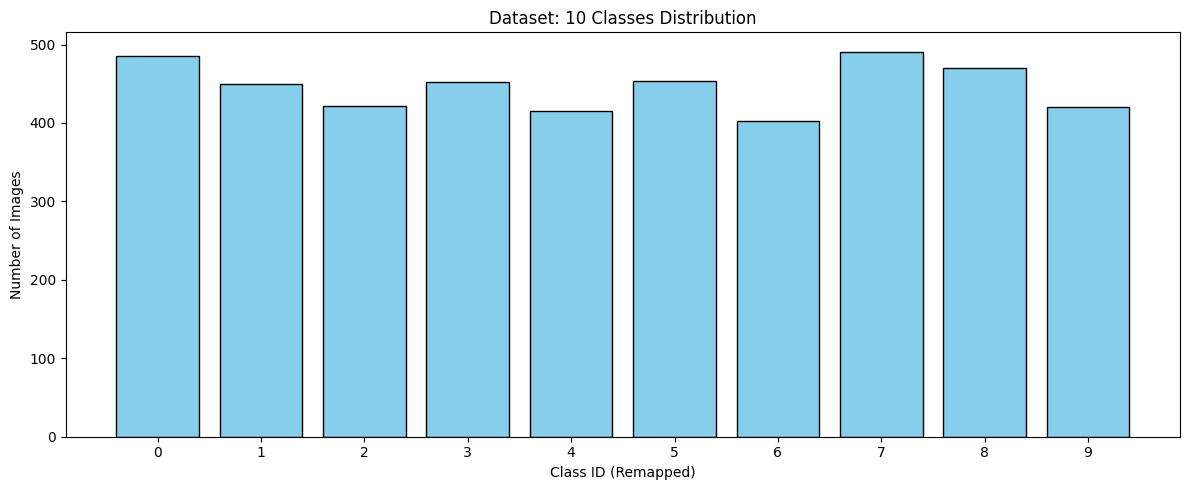

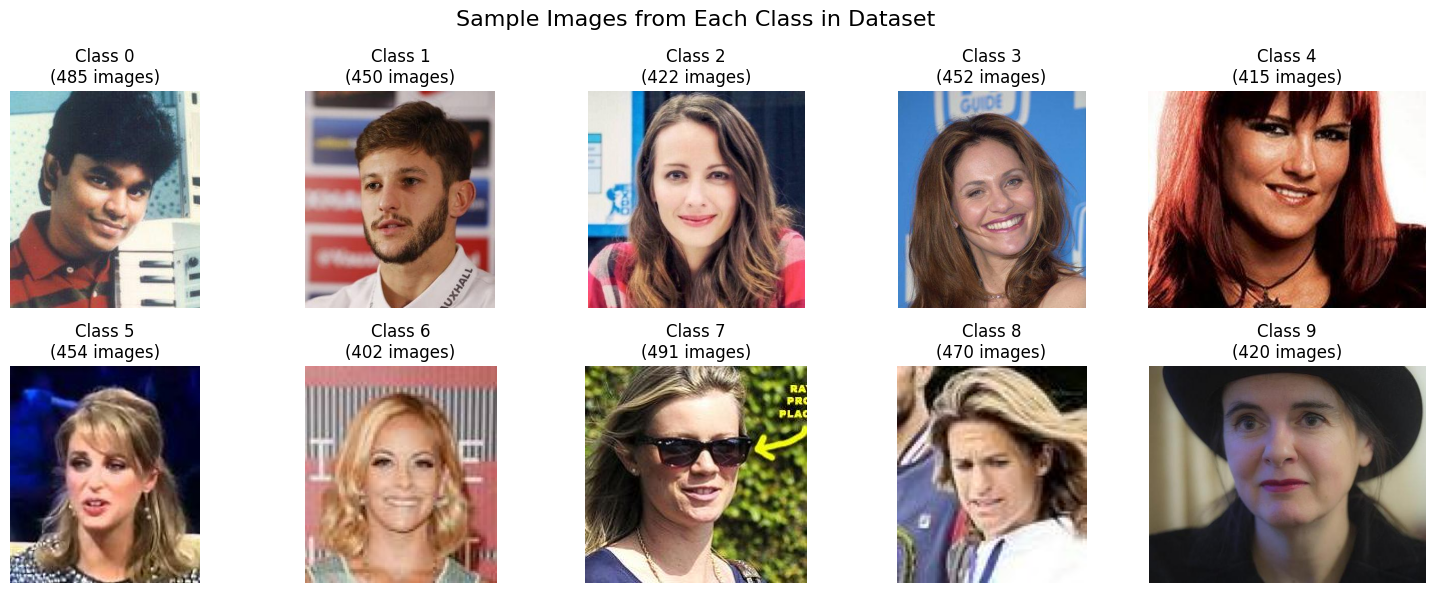

In [7]:
# 2. After Subsetting: Show Selected Classes Statistics
print("\n" + "="*60)
print(f"DATASET: {NUM_CLASSES_TO_USE} Classes Selected")
print("="*60)
print(f"Total images in dataset: {len(selected_paths)}")
print(f"Classes used: {unique_lbls}")
print(f"Class distribution:")

unique_selected, counts_selected = np.unique(selected_labels, return_counts=True)
for cls, cnt in zip(unique_selected, counts_selected):
    print(f"  Class {cls}: {cnt} images")

# Visualize subset class distribution
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(unique_selected, counts_selected, color='skyblue', edgecolor='black')
ax.set_xlabel('Class ID (Remapped)')
ax.set_ylabel('Number of Images')
ax.set_title(f'Dataset: {NUM_CLASSES_TO_USE} Classes Distribution')
ax.set_xticks(unique_selected)
plt.tight_layout()
plt.show()

# Show sample images from selected subset (one per class)
n_cols = 5
n_rows = int(np.ceil(NUM_CLASSES_TO_USE / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
axes = axes.flatten()

for cls in unique_selected:
    cls_indices = np.where(selected_labels == cls)[0]
    sample_idx = np.random.choice(cls_indices)
    sample_path = selected_paths[sample_idx]
    
    img = Image.open(sample_path).convert('RGB')
    axes[cls].imshow(img)
    axes[cls].set_title(f'Class {cls}\n({counts_selected[cls]} images)')
    axes[cls].axis('off')

# Hide extra subplots
for idx in range(NUM_CLASSES_TO_USE, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Images from Each Class in Dataset', fontsize=16)
plt.tight_layout()
plt.show()

## 2.1 Train-Test Split Visualization
After splitting the data, let's visualize the distribution and sample images from both sets.


Training Set Samples:


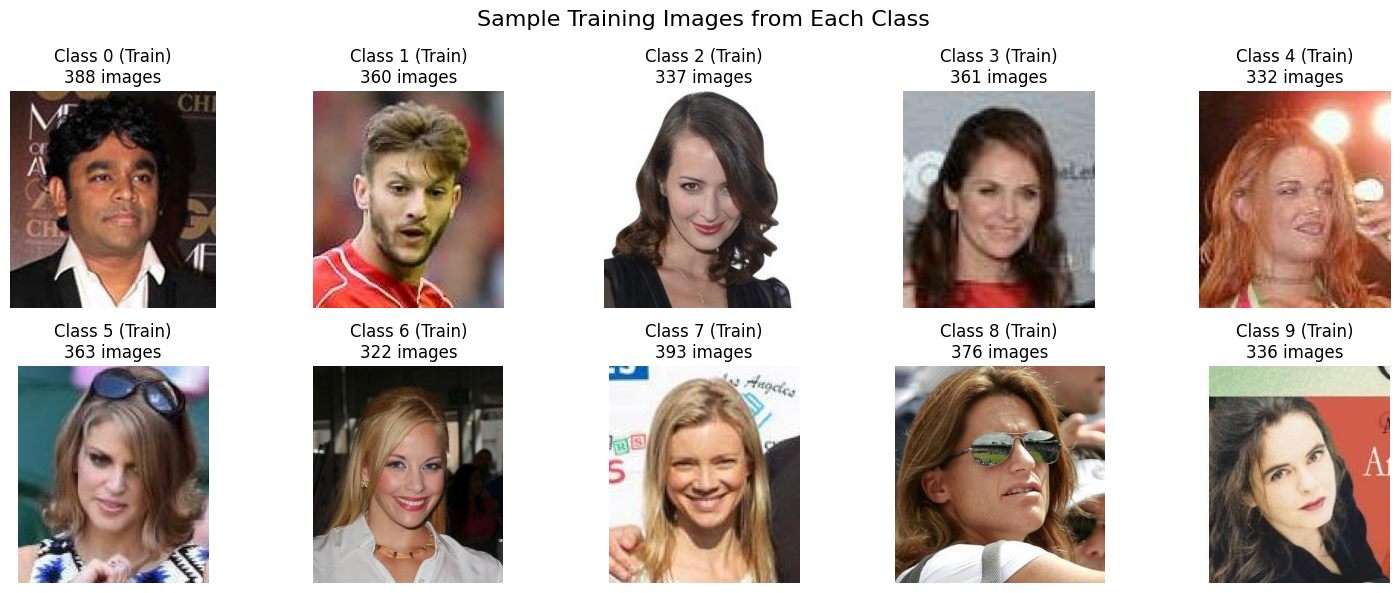


Test Set Samples:


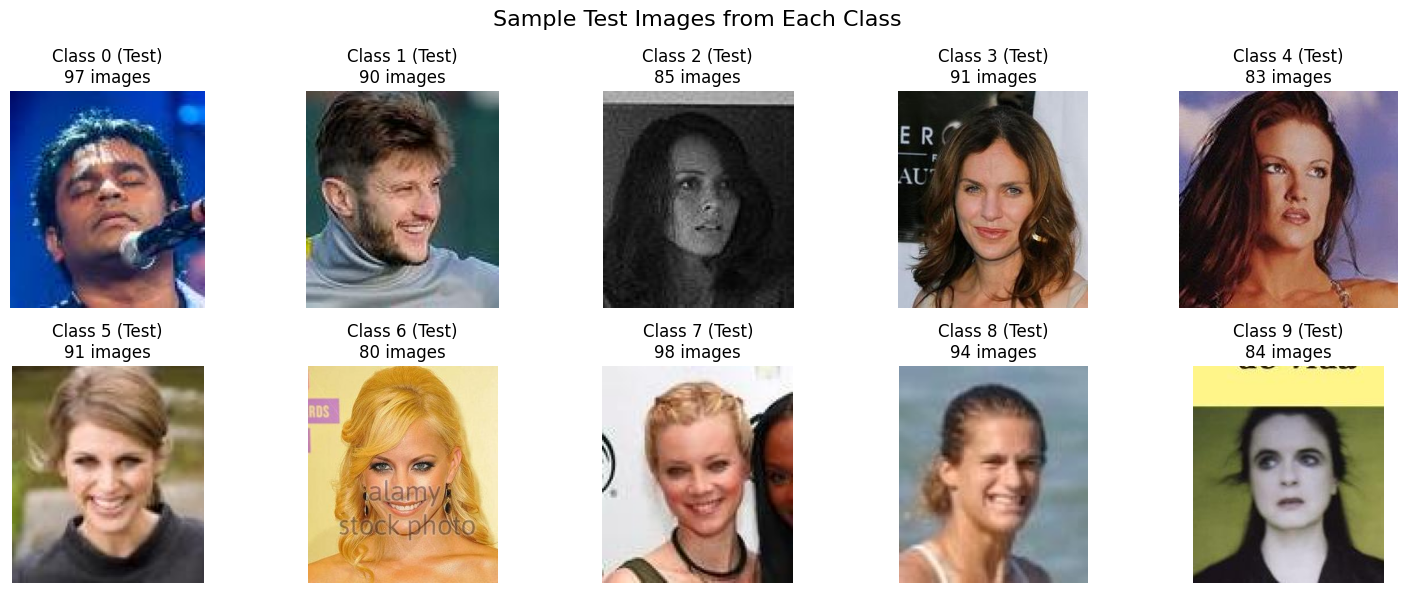


Multiple samples from each class:


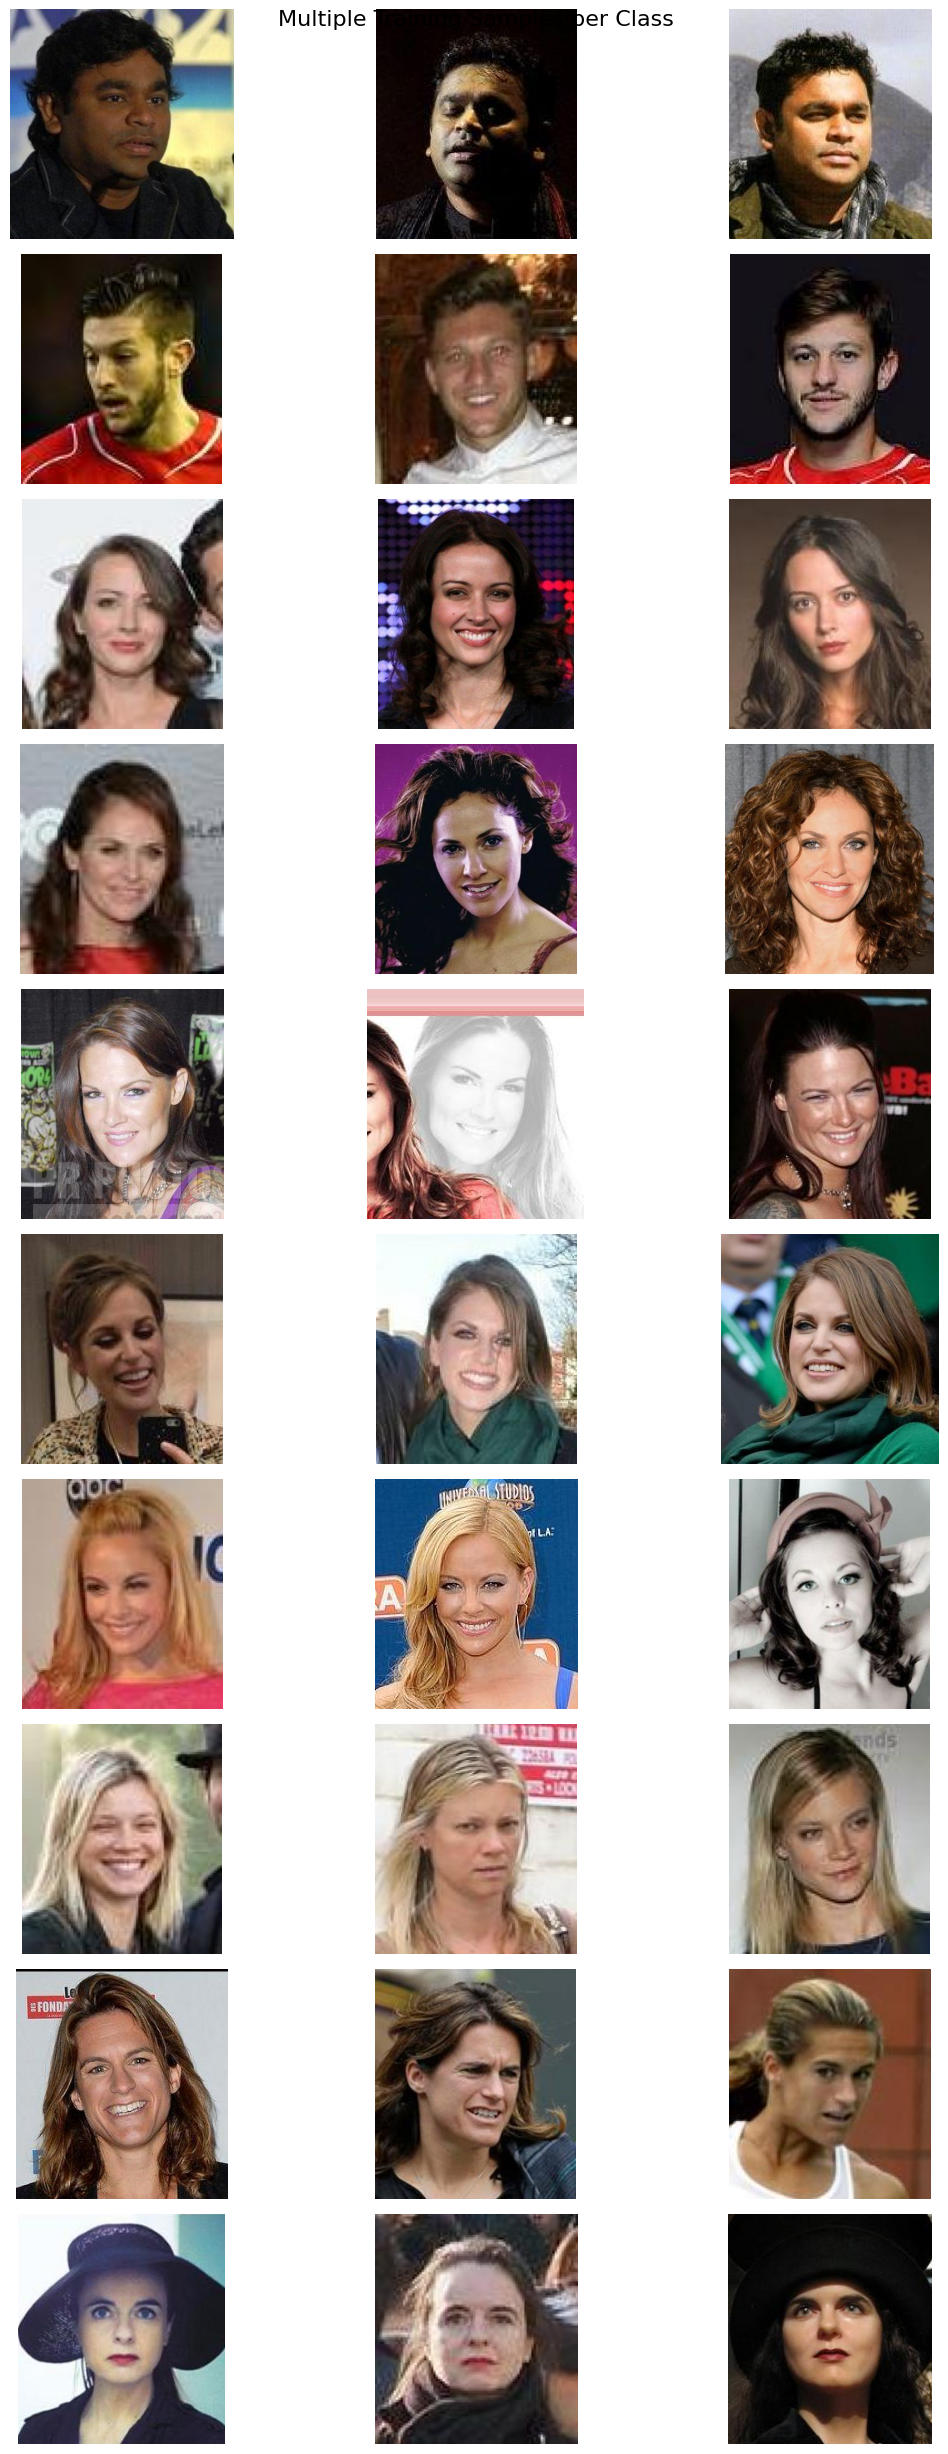

In [14]:
# Sample Images from Each Class (Train Set)
print("\nTraining Set Samples:")
n_cols = 5
n_rows = int(np.ceil(NUM_CLASSES_TO_USE / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
axes = axes.flatten()

for cls in np.unique(y_train):
    cls_indices = np.where(y_train == cls)[0]
    sample_idx = np.random.choice(cls_indices)
    sample_path = train_paths[sample_idx]
    
    img = Image.open(sample_path).convert('RGB')
    axes[cls].imshow(img)
    axes[cls].set_title(f'Class {cls} (Train)\n{np.sum(y_train == cls)} images')
    axes[cls].axis('off')

for idx in range(NUM_CLASSES_TO_USE, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Training Images from Each Class', fontsize=16)
plt.tight_layout()
plt.show()

# Sample Images from Each Class (Test Set)
print("\nTest Set Samples:")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
axes = axes.flatten()

for cls in np.unique(y_test):
    cls_indices = np.where(y_test == cls)[0]
    sample_idx = np.random.choice(cls_indices)
    sample_path = test_paths[sample_idx]
    
    img = Image.open(sample_path).convert('RGB')
    axes[cls].imshow(img)
    axes[cls].set_title(f'Class {cls} (Test)\n{np.sum(y_test == cls)} images')
    axes[cls].axis('off')

for idx in range(NUM_CLASSES_TO_USE, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Test Images from Each Class', fontsize=16)
plt.tight_layout()
plt.show()

# Multiple samples per class (Grid view)
print("\nMultiple samples from each class:")
samples_per_class = 3
fig, axes = plt.subplots(NUM_CLASSES_TO_USE, samples_per_class, figsize=(12, 2.5*NUM_CLASSES_TO_USE))

for cls_idx, cls in enumerate(np.unique(y_train)):
    cls_indices = np.where(y_train == cls)[0]
    sample_indices = np.random.choice(cls_indices, min(samples_per_class, len(cls_indices)), replace=False)
    
    for sample_idx, img_idx in enumerate(sample_indices):
        sample_path = train_paths[img_idx]
        img = Image.open(sample_path).convert('RGB')
        
        if NUM_CLASSES_TO_USE == 1:
            axes[sample_idx].imshow(img)
            axes[sample_idx].axis('off')
            if sample_idx == 0:
                axes[sample_idx].set_title(f'Class {cls}', fontsize=12, fontweight='bold')
        else:
            axes[cls_idx, sample_idx].imshow(img)
            axes[cls_idx, sample_idx].axis('off')
            if sample_idx == 0:
                axes[cls_idx, sample_idx].set_ylabel(f'Class {cls}', fontsize=12, fontweight='bold')

plt.suptitle('Multiple Training Samples per Class', fontsize=16)
plt.tight_layout()
plt.show()

## 2.1 Data Visualization
Here we visualize the dataset characteristics and preprocessing steps.



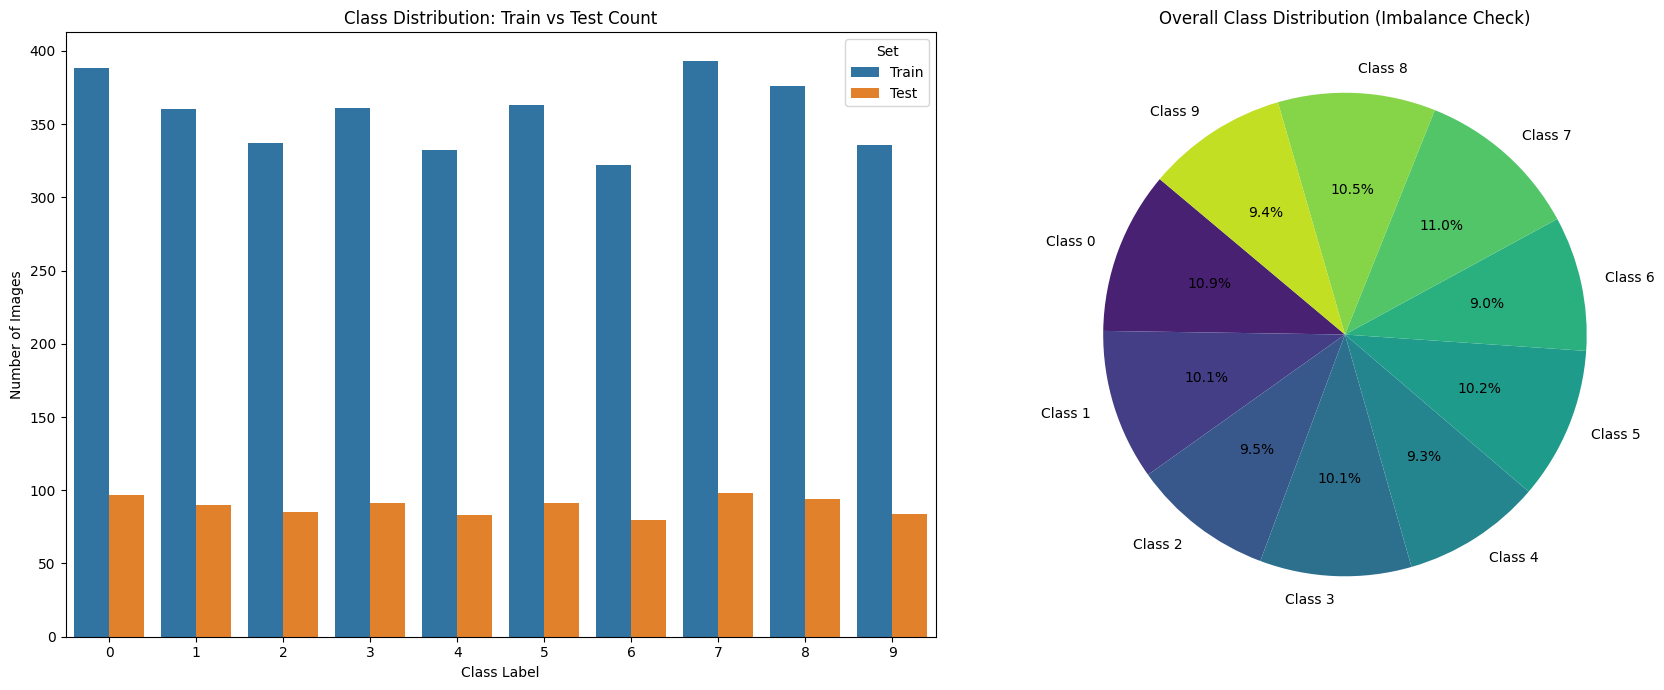

Dataset Split Summary:
Total Train Images: 3568
Total Test Images: 893
Number of Classes: 10
------------------------------
Class 0: Train=388, Test=97, Total=485
Class 1: Train=360, Test=90, Total=450
Class 2: Train=337, Test=85, Total=422
Class 3: Train=361, Test=91, Total=452
Class 4: Train=332, Test=83, Total=415
Class 5: Train=363, Test=91, Total=454
Class 6: Train=322, Test=80, Total=402
Class 7: Train=393, Test=98, Total=491
Class 8: Train=376, Test=94, Total=470
Class 9: Train=336, Test=84, Total=420
------------------------------
Effective Training Data Size per Epoch: 3568
Total 'Unique' Views seen by model over 10 epochs: 35680 (due to random augmentation)


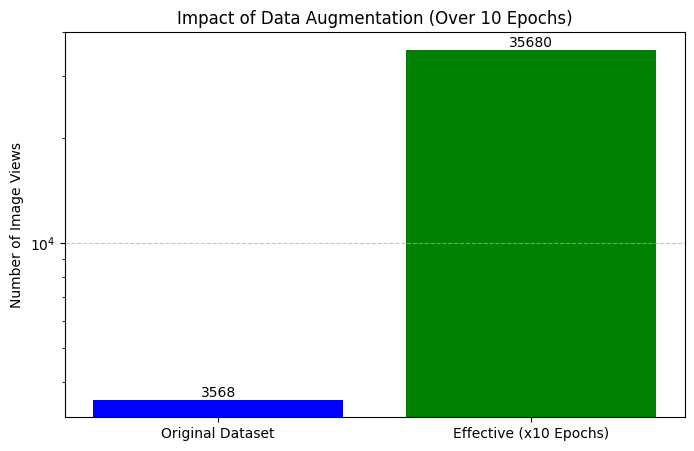

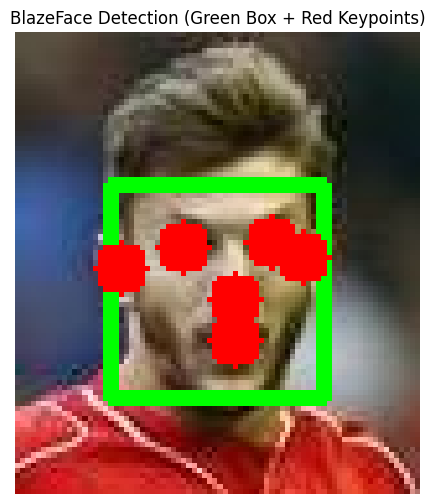

Visualizing Augmentation (MobileFaceNet Pipeline)...


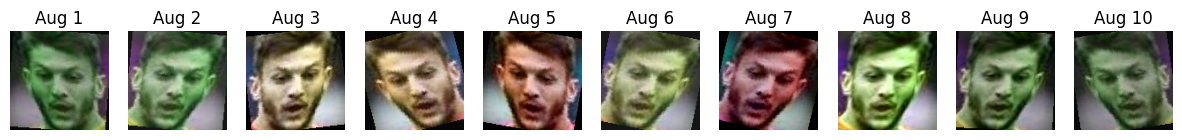

In [9]:
# 1. Class Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

# DataFrame for plotting
import pandas as pd
df_train = pd.DataFrame({'Class': unique_train, 'Count': counts_train, 'Set': 'Train'})
df_test = pd.DataFrame({'Class': unique_test, 'Count': counts_test, 'Set': 'Test'})
df_counts = pd.concat([df_train, df_test])

# 1a. Stacked Bar Chart (Train vs Test)
sns.barplot(data=df_counts, x='Class', y='Count', hue='Set', ax=axes[0])
axes[0].set_title('Class Distribution: Train vs Test Count')
axes[0].set_xlabel('Class Label')
axes[0].set_ylabel('Number of Images')

# 1b. Pie Chart (Overall Class Imbalance)
total_counts = {}
for c, n in zip(unique_train, counts_train): total_counts[c] = total_counts.get(c, 0) + n
for c, n in zip(unique_test, counts_test): total_counts[c] = total_counts.get(c, 0) + n

labels_pie = [f"Class {k}" for k in total_counts.keys()]
sizes_pie = list(total_counts.values())

axes[1].pie(sizes_pie, labels=labels_pie, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("viridis", len(sizes_pie)))
axes[1].set_title('Overall Class Distribution (Imbalance Check)')

plt.tight_layout()
plt.show()

# 1c. Text Summary
print("Dataset Split Summary:")
print(f"Total Train Images: {len(train_paths)}")
print(f"Total Test Images: {len(test_paths)}")
print(f"Number of Classes: {len(unique_train)}")
print("-" * 30)
for c in unique_train:
    n_train = counts_train[np.where(unique_train == c)][0]
    n_test = counts_test[np.where(unique_test == c)][0] if c in unique_test else 0
    print(f"Class {c}: Train={n_train}, Test={n_test}, Total={n_train+n_test}")

# 1d. Effective Data Size (Augmentation)
# Assuming 10 epochs of random augmentation
EPOCHS_DEMO = 10
print("-" * 30)
print(f"Effective Training Data Size per Epoch: {len(train_paths)}")
print(f"Total 'Unique' Views seen by model over {EPOCHS_DEMO} epochs: {len(train_paths) * EPOCHS_DEMO} (due to random augmentation)")

# Visualize "Effective" vs "Original"
plt.figure(figsize=(8, 5))
plt.bar(['Original Dataset', f'Effective (x{EPOCHS_DEMO} Epochs)'], [len(train_paths), len(train_paths)*EPOCHS_DEMO], color=['blue', 'green'])
plt.title(f'Impact of Data Augmentation (Over {EPOCHS_DEMO} Epochs)')
plt.ylabel('Number of Image Views')
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate([len(train_paths), len(train_paths)*EPOCHS_DEMO]):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()

# 2. BlazeFace Detection Visualization
def visualize_detection(image_path):
    if not os.path.exists(image_path): return
    
    # Use the aligner's detector
    mp_image = mp.Image.create_from_file(image_path)
    detection_result = aligner.detector.detect(mp_image)
    
    img_display = cv2.imread(image_path)
    img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
    
    if detection_result.detections:
        for detection in detection_result.detections:
            bbox = detection.bounding_box
            start_point = (bbox.origin_x, bbox.origin_y)
            end_point = (bbox.origin_x + bbox.width, bbox.origin_y + bbox.height)
            cv2.rectangle(img_display, start_point, end_point, (0, 255, 0), 2)
            
            # Keypoints
            for kp in detection.keypoints:
                x = int(kp.x * img_display.shape[1])
                y = int(kp.y * img_display.shape[0])
                cv2.circle(img_display, (x, y), 5, (255, 0, 0), -1)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_display)
    plt.title("BlazeFace Detection (Green Box + Red Keypoints)")
    plt.axis('off')
    plt.show()

# Visualize a random training image
if len(train_paths) > 0:
    visualize_detection(train_paths[0])

# 3. Augmentation Visualization
print("Visualizing Augmentation (MobileFaceNet Pipeline)...")
# Create a temp dataset in train mode
aug_ds = UnifiedFaceDataset(train_paths[:1], y_train[:1], mode='train', model_type='mobilefacenet')
plt.figure(figsize=(15, 3))
for i in range(10):
    img_tensor, _ = aug_ds[0] # Returns tensor C,H,W
    # Denormalize for display: [-1,1] -> [0,1]
    img = img_tensor.permute(1, 2, 0).numpy() * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    
    plt.subplot(1, 10, i+1)
    plt.imshow(img)
    plt.title(f"Aug {i+1}")
    plt.axis('off')
plt.show()



## 2.2 Advanced Data Analysis (Raw Features)
Before feeding data into deep learning models, let's visualize the raw pixel data using dimensionality reduction (PCA & T-SNE). 
This helps us see if classes are separable even without complex training.



## 3. Model Training & Evaluation Functions
Define helper functions for training and evaluation.

In [11]:
results = {}
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize

def evaluate_features(train_embs, train_labels, test_embs, test_labels, model_name, use_cosine=True):
    print(f"Evaluating features for {model_name}...")
    
    # Normalization strategy based on model type
    if use_cosine:
        # For deep learning models: normalize for cosine similarity
        train_norms = np.linalg.norm(train_embs, axis=1, keepdims=True)
        test_norms = np.linalg.norm(test_embs, axis=1, keepdims=True)
        train_embs = train_embs / np.maximum(train_norms, 1e-10)
        test_embs = test_embs / np.maximum(test_norms, 1e-10)
        metric = 'cosine'
    else:
        # For PCA/LBPH: use Euclidean distance (no normalization)
        metric = 'euclidean'
    
    # 1. Identification (Rank-1 Accuracy & Confusion Matrix)
    # Use 1-NN Classifier as a proxy for Identification
    knn = KNeighborsClassifier(n_neighbors=1, metric=metric)
    knn.fit(train_embs, train_labels)
    y_pred = knn.predict(test_embs)
    
    acc = accuracy_score(test_labels, y_pred)
    cm = confusion_matrix(test_labels, y_pred)
    
    # 2. Verification (Pairwise AUC)
    n_pairs = 3000
    sims, true_labels_pairs = [], []
    unique_cls = np.unique(test_labels)
    
    # Optimize pair generation
    for _ in range(n_pairs):
        if np.random.rand() > 0.5: # Same
            c = np.random.choice(unique_cls)
            idxs = np.where(test_labels == c)[0]
            if len(idxs) < 2: continue
            i, j = np.random.choice(idxs, 2, replace=False)
            if use_cosine:
                sims.append(np.dot(test_embs[i], test_embs[j]))
            else:
                # For Euclidean: use negative distance so smaller distance = higher similarity
                dist = np.linalg.norm(test_embs[i] - test_embs[j])
                sims.append(-dist)  # Negative so smaller distance gives higher score
            true_labels_pairs.append(1)
        else: # Diff
            c1, c2 = np.random.choice(unique_cls, 2, replace=False)
            i = np.random.choice(np.where(test_labels == c1)[0])
            j = np.random.choice(np.where(test_labels == c2)[0])
            if use_cosine:
                sims.append(np.dot(test_embs[i], test_embs[j]))
            else:
                dist = np.linalg.norm(test_embs[i] - test_embs[j])
                sims.append(-dist)  # Negative so smaller distance gives higher score
            true_labels_pairs.append(0)
    
    if len(true_labels_pairs) > 0:
        auc_score = roc_auc_score(true_labels_pairs, sims)
        fpr, tpr, _ = roc_curve(true_labels_pairs, sims)
        
        # 3. Precision-Recall Curve for Verification
        precision, recall, _ = precision_recall_curve(true_labels_pairs, sims)
        avg_precision = average_precision_score(true_labels_pairs, sims)
    else:
        auc_score = 0.0
        fpr, tpr = [0, 1], [0, 1]
        precision, recall = [1, 0], [0, 1]
        avg_precision = 0.0
    
    return {
        'auc': auc_score, 
        'acc': acc, 
        'fpr': fpr, 
        'tpr': tpr, 
        'cm': cm, 
        'y_true': test_labels, 
        'y_pred': y_pred,
        'precision': precision,
        'recall': recall,
        'avg_precision': avg_precision,
        'test_embeddings': test_embs  # Store for later analysis
    }

def train_eval_dl_model(model_class, name, embedding_size, img_size_mode):
    print(f"\n=== Processing {name} ===")
    
    # Datasets
    train_ds = UnifiedFaceDataset(train_paths, y_train, mode='train', model_type=img_size_mode)
    test_ds = UnifiedFaceDataset(test_paths, y_test, mode='test', model_type=img_size_mode)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # For extraction
    train_ds_eval = UnifiedFaceDataset(train_paths, y_train, mode='test', model_type=img_size_mode)
    train_eval_dl = DataLoader(train_ds_eval, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Model
    model = model_class(embedding_size=embedding_size).to(device)
    metric_fc = losses.ArcFaceLoss(num_classes=NUM_CLASSES_TO_USE, embedding_size=embedding_size).to(device)
    optimizer = optim.SGD([{'params': model.parameters()}, {'params': metric_fc.parameters()}], lr=0.01, momentum=0.9)
    
    # Learning Rate Scheduler
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
    
    # Early Stopping Setup
    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0
    best_model_state = None
    
    # Train Loop
    epochs = 80 
    loss_history = []
    val_loss_history = []
    acc_history = []
    val_acc_history = []
    
    model.train()
    for ep in range(epochs):
        # Training Phase
        model.train()
        loss_val = 0
        
        for imgs, lbls in train_dl:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            emb = model(imgs)
            loss = metric_fc(emb, lbls)
            loss.backward()
            optimizer.step()
            loss_val += loss.item()
            
        epoch_loss = loss_val/len(train_dl)
        loss_history.append(epoch_loss)
        
        # Validation Phase
        model.eval()
        val_loss_val = 0
        
        with torch.no_grad():
            for imgs, lbls in test_dl:
                imgs, lbls = imgs.to(device), lbls.to(device)
                emb = model(imgs)
                loss = metric_fc(emb, lbls) 
                val_loss_val += loss.item()
        
        epoch_val_loss = val_loss_val/len(test_dl)
        val_loss_history.append(epoch_val_loss)
        
        # Early Stopping Check
        if epoch_val_loss < best_val_loss - 0.001:  # min_delta = 0.001
            best_val_loss = epoch_val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
            print(f"  → New best validation loss: {best_val_loss:.4f}")
        else:
            patience_counter += 1
            print(f"  → No improvement ({patience_counter}/{patience})")
            
        if patience_counter >= patience:
            print(f"\n⚠️ Early stopping triggered at epoch {ep+1}")
            print(f"Best validation loss: {best_val_loss:.4f}")
            if best_model_state is not None:
                model.load_state_dict(best_model_state)
                print("Restored best model weights")
            break
        
        # Step the learning rate scheduler
        scheduler.step()
        
        # Calculate accuracy every 5 epochs
        if (ep + 1) % 5 == 0 or ep == 0:
            def quick_acc(loader):
                model.eval()
                all_embs, all_lbls = [], []
                with torch.no_grad():
                    for imgs, lbls in loader:
                        embs = model(imgs.to(device)).cpu().numpy()
                        all_embs.append(embs)
                        all_lbls.append(lbls.numpy())
                all_embs = np.concatenate(all_embs)
                all_lbls = np.concatenate(all_lbls)
                
                # Normalize
                all_embs = all_embs / np.maximum(np.linalg.norm(all_embs, axis=1, keepdims=True), 1e-10)
                
                # 1-NN
                if len(all_embs) < 2:
                    return 0.0
                knn = KNeighborsClassifier(n_neighbors=1, metric='cosine')
                knn.fit(all_embs, all_lbls)
                preds = knn.predict(all_embs)
                return accuracy_score(all_lbls, preds)
            
            train_acc = quick_acc(train_eval_dl)
            val_acc = quick_acc(test_dl)
            acc_history.append(train_acc)
            val_acc_history.append(val_acc)
            print(f"{name}: Epoch {ep+1} Train Loss: {epoch_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
        else:
            acc_history.append(acc_history[-1] if acc_history else 0)
            val_acc_history.append(val_acc_history[-1] if val_acc_history else 0)
            print(f"{name}: Epoch {ep+1} Train Loss: {epoch_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")
        
    # Save model
    os.makedirs('final_models', exist_ok=True)
    save_path = os.path.join('final_models', f"{name}.pth")
    torch.save(model.state_dict(), save_path)
    print(f"Saved {name} model to {save_path}")

    # Extract Embeddings
    model.eval()
    def extract(loader):
        embs, lbls = [], []
        with torch.no_grad():
            for imgs, l in loader:
                embs.append(model(imgs.to(device)).cpu().numpy())
                lbls.append(l.numpy())
        return np.concatenate(embs), np.concatenate(lbls)

    train_embs, train_lbls_out = extract(train_eval_dl)
    test_embs, test_lbls_out = extract(test_dl)
    
    res = evaluate_features(train_embs, train_lbls_out, test_embs, test_lbls_out, name, use_cosine=True)
    results[name] = res
    results[name]['loss_history'] = loss_history
    results[name]['val_loss_history'] = val_loss_history
    results[name]['acc_history'] = acc_history

    results[name]['val_acc_history'] = val_acc_history
    results[name]['val_acc_history'] = val_acc_history    

    print(f"{name} Verification AUC: {res['auc']:.4f}, Rank-1 Acc: {res['acc']:.4f}, Avg Precision: {res['avg_precision']:.4f}")
    print(f"{name} Verification AUC: {res['auc']:.4f}, Rank-1 Acc: {res['acc']:.4f}, Avg Precision: {res['avg_precision']:.4f}")    
    return model, loss_history, val_loss_history


TRAINING MOBILEFACENET

=== Processing MobileFaceNet ===
  → New best validation loss: 32.4513
MobileFaceNet: Epoch 1 Train Loss: 33.2576, Val Loss: 32.4513, Train Acc: 1.0000, Val Acc: 1.0000
  → New best validation loss: 24.6541
MobileFaceNet: Epoch 2 Train Loss: 26.3109, Val Loss: 24.6541
  → New best validation loss: 22.6744
MobileFaceNet: Epoch 3 Train Loss: 22.6604, Val Loss: 22.6744
  → New best validation loss: 21.7298
MobileFaceNet: Epoch 4 Train Loss: 20.0981, Val Loss: 21.7298
  → New best validation loss: 17.3010
MobileFaceNet: Epoch 5 Train Loss: 18.3508, Val Loss: 17.3010, Train Acc: 1.0000, Val Acc: 1.0000
  → New best validation loss: 16.9420
MobileFaceNet: Epoch 6 Train Loss: 16.3724, Val Loss: 16.9420
  → New best validation loss: 13.7661
MobileFaceNet: Epoch 7 Train Loss: 14.9172, Val Loss: 13.7661
  → No improvement (1/10)
MobileFaceNet: Epoch 8 Train Loss: 14.0983, Val Loss: 16.9249
  → New best validation loss: 13.4758
MobileFaceNet: Epoch 9 Train Loss: 12.9213, 

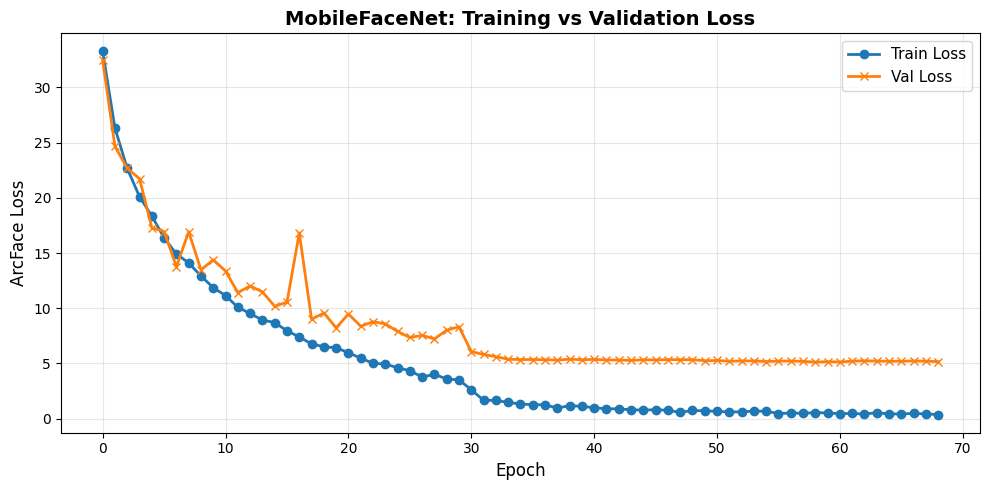


TRAINING EFFICIENTNET

=== Processing EfficientNet ===
  → New best validation loss: 46.3268
EfficientNet: Epoch 1 Train Loss: 28.2094, Val Loss: 46.3268, Train Acc: 1.0000, Val Acc: 1.0000
  → New best validation loss: 20.7169
EfficientNet: Epoch 2 Train Loss: 19.0557, Val Loss: 20.7169
  → New best validation loss: 13.3618
EfficientNet: Epoch 3 Train Loss: 14.5869, Val Loss: 13.3618
  → No improvement (1/10)
EfficientNet: Epoch 4 Train Loss: 11.2833, Val Loss: 16.0639
  → New best validation loss: 10.3461
EfficientNet: Epoch 5 Train Loss: 9.5300, Val Loss: 10.3461, Train Acc: 1.0000, Val Acc: 1.0000
  → New best validation loss: 7.9946
EfficientNet: Epoch 6 Train Loss: 7.5319, Val Loss: 7.9946
  → No improvement (1/10)
EfficientNet: Epoch 7 Train Loss: 7.1399, Val Loss: 10.6420
  → New best validation loss: 6.9088
EfficientNet: Epoch 8 Train Loss: 5.7836, Val Loss: 6.9088
  → New best validation loss: 6.6070
EfficientNet: Epoch 9 Train Loss: 5.1556, Val Loss: 6.6070
  → New best val

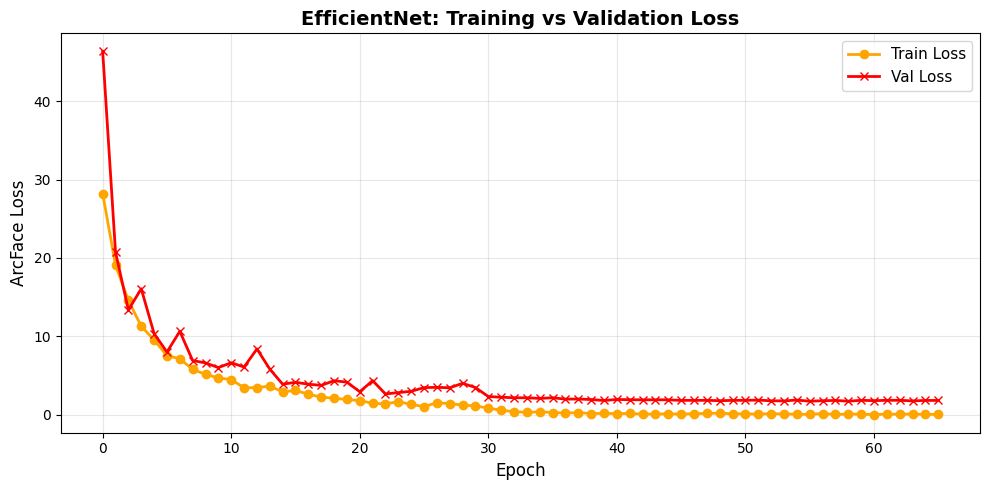

In [12]:
# 1. MobileFaceNet
print("\n" + "="*80)
print("TRAINING MOBILEFACENET")
print("="*80)
_, history_mfn, val_history_mfn = train_eval_dl_model(MobileFaceNet, "MobileFaceNet", 512, 'mobilefacenet')

# Plot MFN Learning Curve
fig, ax = plt.subplots(1, figsize=(10, 5))

# Loss curves
ax.plot(history_mfn, marker='o', label='Train Loss', linewidth=2)
ax.plot(val_history_mfn, marker='x', label='Val Loss', linewidth=2)
ax.set_title('MobileFaceNet: Training vs Validation Loss', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('ArcFace Loss', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. EfficientNet
print("\n" + "="*80)
print("TRAINING EFFICIENTNET")
print("="*80)
_, history_eff, val_history_eff = train_eval_dl_model(lambda embedding_size: EfficientNetArcFace(embedding_size), "EfficientNet", 1280, 'efficientnet')

# Plot EffNet Learning Curves
# Plot EffNet Learning Curve
fig, ax = plt.subplots(1, figsize=(10, 5))
# Loss curves
axes[0].plot(history_eff, marker='o', label='Train Loss', linewidth=2, color='orange')
ax.plot(history_eff, marker='o', label='Train Loss', linewidth=2, color='orange')
ax.plot(val_history_eff, marker='x', label='Val Loss', linewidth=2, color='red')
ax.set_title('EfficientNet: Training vs Validation Loss', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('ArcFace Loss', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




TRAINING PCA (EIGENFACES)
Training PCA...
PCA Training Complete.
Saved PCA model to final_models/pca_model.npz
Evaluating features for PCA...
PCA Verification AUC: 0.5830, Rank-1 Acc: 0.5465, Avg Precision: 0.5761

Visualizing Top Eigenfaces:


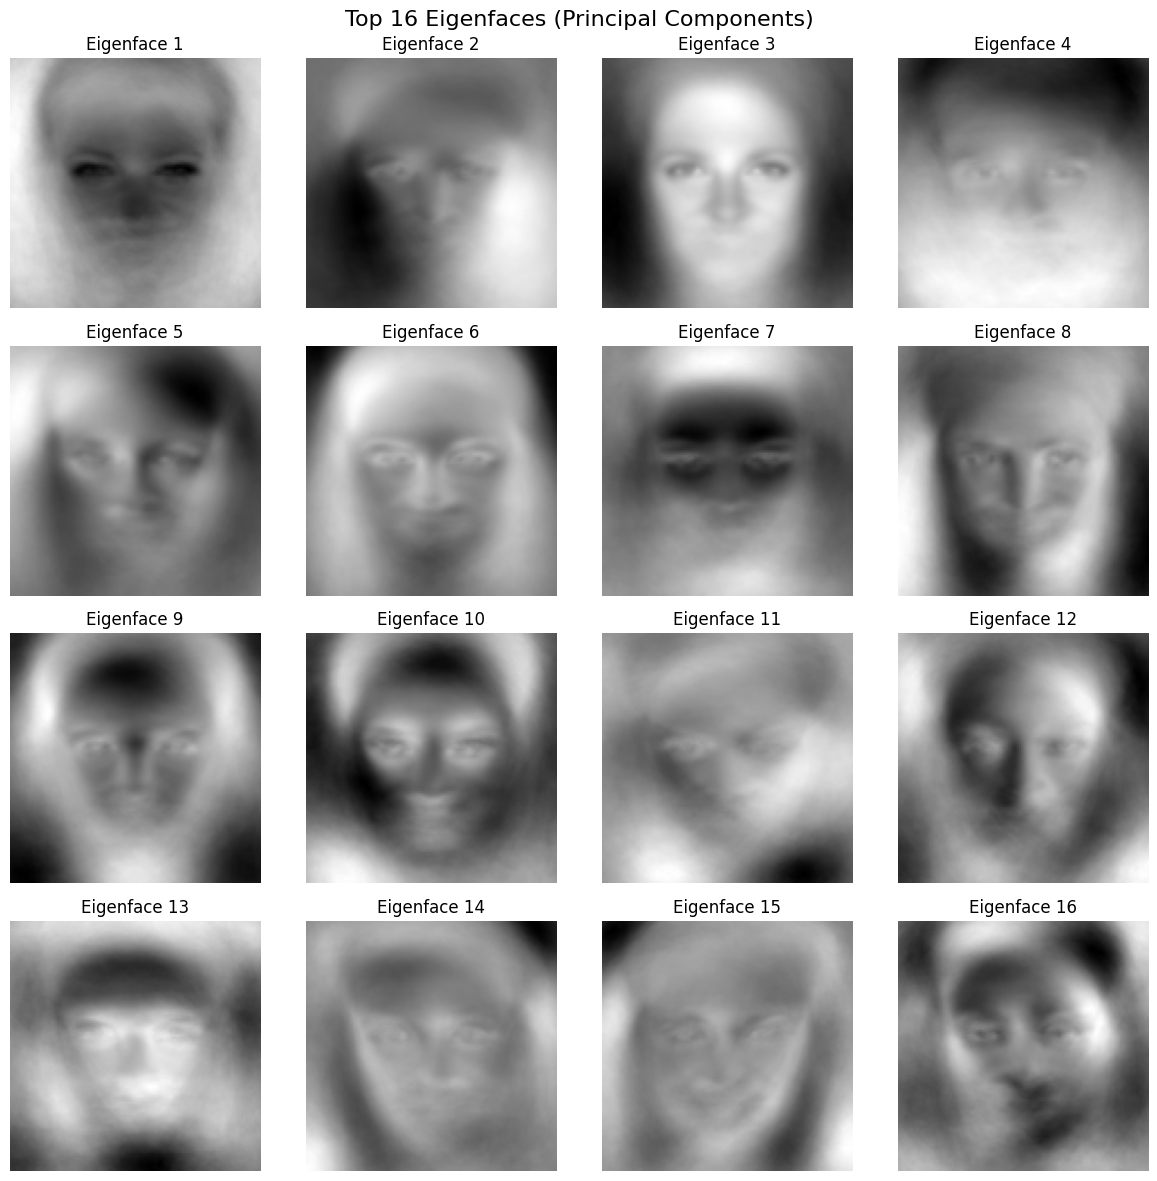


TRAINING LBPH
Saved LBPH model to final_models/lbph_model.yml
Computing LBPH verification metrics...
LBPH Rank-1 Accuracy: 0.7335, AUC: 0.5080, Avg Precision: 0.4830


In [13]:
# Prepare Data arrays
def load_data_array(mode, model_type):
    ds = UnifiedFaceDataset(train_paths if mode=='train' else test_paths, 
                            y_train if mode=='train' else y_test, 
                            mode='test', 
                            model_type=model_type)
    data = []
    labels = []
    for i in range(len(ds)):
        d, l = ds[i]
        data.append(d)
        labels.append(l)
    return np.array(data), np.array(labels)

# --- 3. PCA ---
print("\n" + "="*80)
print("TRAINING PCA (EIGENFACES)")
print("="*80)
X_train_pca, Y_train_pca = load_data_array('train', 'pca')
X_test_pca, Y_test_pca = load_data_array('test', 'pca')

pca = PCAModel(n_components=150)
pca.fit(X_train_pca, Y_train_pca)

# Save PCA
os.makedirs('final_models', exist_ok=True)
np.savez('final_models/pca_model.npz', 
         mean=pca.mean_face, 
         eigenfaces=pca.eigenfaces, 
         projections=pca.projections, 
         labels=pca.labels)
print("Saved PCA model to final_models/pca_model.npz")

train_embs_pca = pca.get_embeddings(X_train_pca)
test_embs_pca = pca.get_embeddings(X_test_pca)
res_pca = evaluate_features(train_embs_pca, Y_train_pca, test_embs_pca, Y_test_pca, "PCA", use_cosine=False)
results["PCA"] = res_pca
results["PCA"]['loss_history'] = []  # PCA doesn't have iterative training
results["PCA"]['val_loss_history'] = []
results["PCA"]['acc_history'] = []
results["PCA"]['val_acc_history'] = []
print(f"PCA Verification AUC: {res_pca['auc']:.4f}, Rank-1 Acc: {res_pca['acc']:.4f}, Avg Precision: {res_pca['avg_precision']:.4f}")

# Visualize Eigenfaces
print("\nVisualizing Top Eigenfaces:")
n_eigenfaces_viz = min(16, pca.n_components)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for i in range(n_eigenfaces_viz):
    eigenface = pca.eigenfaces[i].reshape(112, 112)
    axes[i].imshow(eigenface, cmap='gray')
    axes[i].set_title(f'Eigenface {i+1}')
    axes[i].axis('off')

plt.suptitle('Top 16 Eigenfaces (Principal Components)', fontsize=16)
plt.tight_layout()
plt.show()

# --- 4. LBPH ---
print("\n" + "="*80)
print("TRAINING LBPH")
print("="*80)
X_train_lbph, Y_train_lbph = load_data_array('train', 'lbph')
X_test_lbph, Y_test_lbph = load_data_array('test', 'lbph')

lbph = cv2.face.LBPHFaceRecognizer_create()
lbph.train(X_train_lbph, Y_train_lbph)

# Save LBPH
lbph.write('final_models/lbph_model.yml')
print("Saved LBPH model to final_models/lbph_model.yml")

y_pred_lbph = []
confidences_lbph = []
for img in X_test_lbph:
    p_lbl, conf = lbph.predict(img)
    y_pred_lbph.append(p_lbl)
    confidences_lbph.append(conf)

# Use confidence scores as pseudo-embeddings (1D)
lbph_embeddings = np.array(confidences_lbph).reshape(-1, 1)
    
acc_lbph = accuracy_score(Y_test_lbph, y_pred_lbph)
cm_lbph = confusion_matrix(Y_test_lbph, y_pred_lbph)

# For LBPH, we can compute a simple ROC using confidence scores (inverted)
# Lower confidence = higher similarity in LBPH
# Create verification pairs for LBPH
print("Computing LBPH verification metrics...")
n_pairs_lbph = 1000
sims_lbph, true_labels_lbph = [], []
unique_cls = np.unique(Y_test_lbph)

for _ in range(n_pairs_lbph):
    if np.random.rand() > 0.5:  # Same
        c = np.random.choice(unique_cls)
        idxs = np.where(Y_test_lbph == c)[0]
        if len(idxs) < 2: continue
        i, j = np.random.choice(idxs, 2, replace=False)
        _, conf = lbph.predict(X_test_lbph[i])
        # Use negative confidence as similarity (lower conf = more similar)
        sims_lbph.append(-conf)
        true_labels_lbph.append(1)
    else:  # Different
        c1, c2 = np.random.choice(unique_cls, 2, replace=False)
        i = np.random.choice(np.where(Y_test_lbph == c1)[0])
        j = np.random.choice(np.where(Y_test_lbph == c2)[0])
        _, conf = lbph.predict(X_test_lbph[i])
        sims_lbph.append(-conf)
        true_labels_lbph.append(0)

if len(true_labels_lbph) > 0:
    auc_lbph = roc_auc_score(true_labels_lbph, sims_lbph)
    fpr_lbph, tpr_lbph, _ = roc_curve(true_labels_lbph, sims_lbph)
    precision_lbph, recall_lbph, _ = precision_recall_curve(true_labels_lbph, sims_lbph)
    avg_precision_lbph = average_precision_score(true_labels_lbph, sims_lbph)
else:
    auc_lbph = 0.0
    fpr_lbph, tpr_lbph = [0, 1], [0, 1]
    precision_lbph, recall_lbph = [1, 0], [0, 1]
    avg_precision_lbph = 0.0

results["LBPH"] = {
    'auc': auc_lbph, 
    'acc': acc_lbph, 
    'fpr': fpr_lbph, 
    'tpr': tpr_lbph, 
    'cm': cm_lbph, 
    'y_true': Y_test_lbph, 
    'y_pred': y_pred_lbph,
    'precision': precision_lbph,
    'recall': recall_lbph,
    'avg_precision': avg_precision_lbph,
    'loss_history': [],
    'val_loss_history': [],
    'acc_history': [],
    'val_acc_history': [],
    'test_embeddings': lbph_embeddings  # Store confidence scores as embeddings
}
print(f"LBPH Rank-1 Accuracy: {acc_lbph:.4f}, AUC: {auc_lbph:.4f}, Avg Precision: {avg_precision_lbph:.4f}")




MODEL COMPARISON ANALYSIS


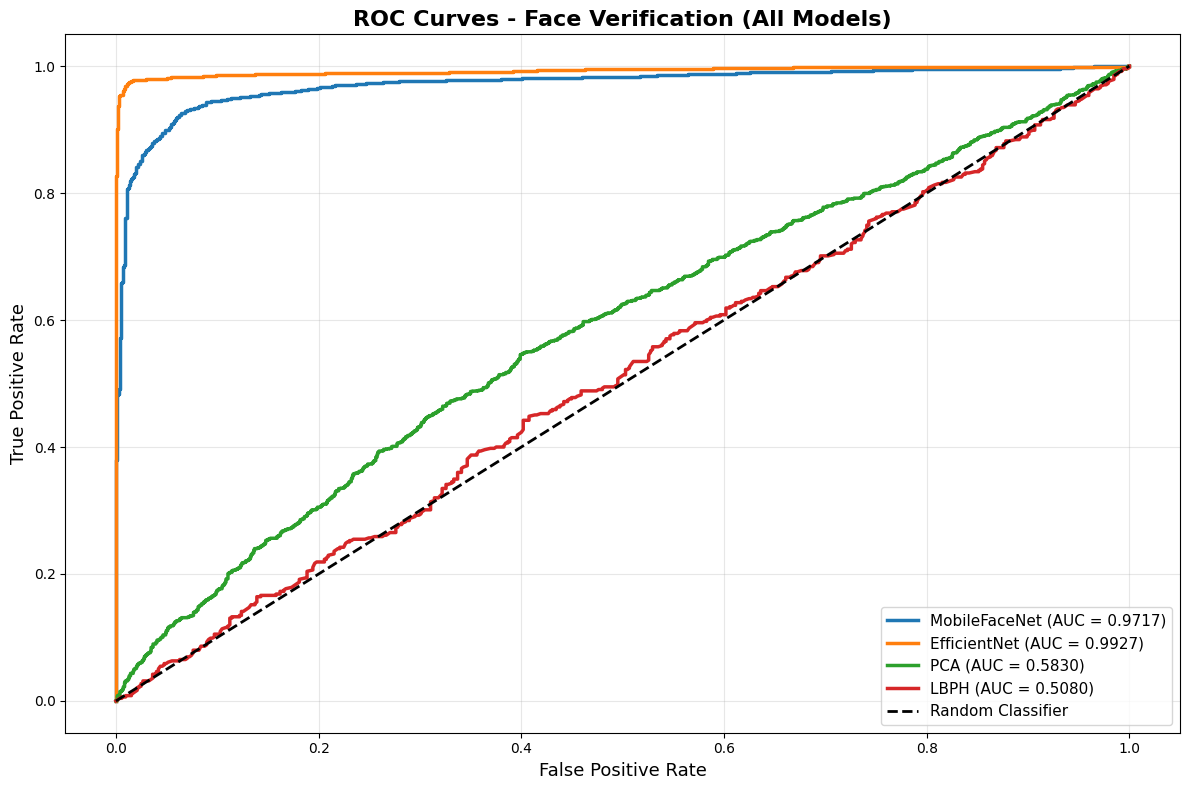

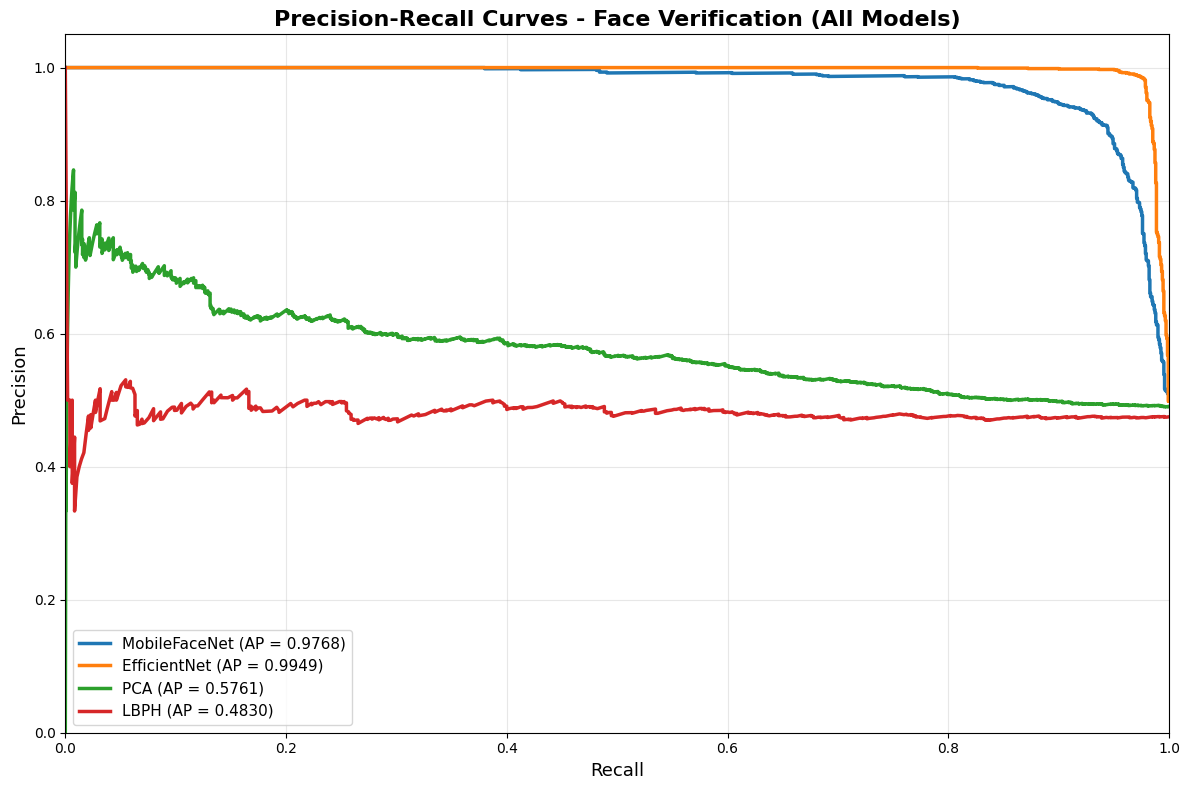

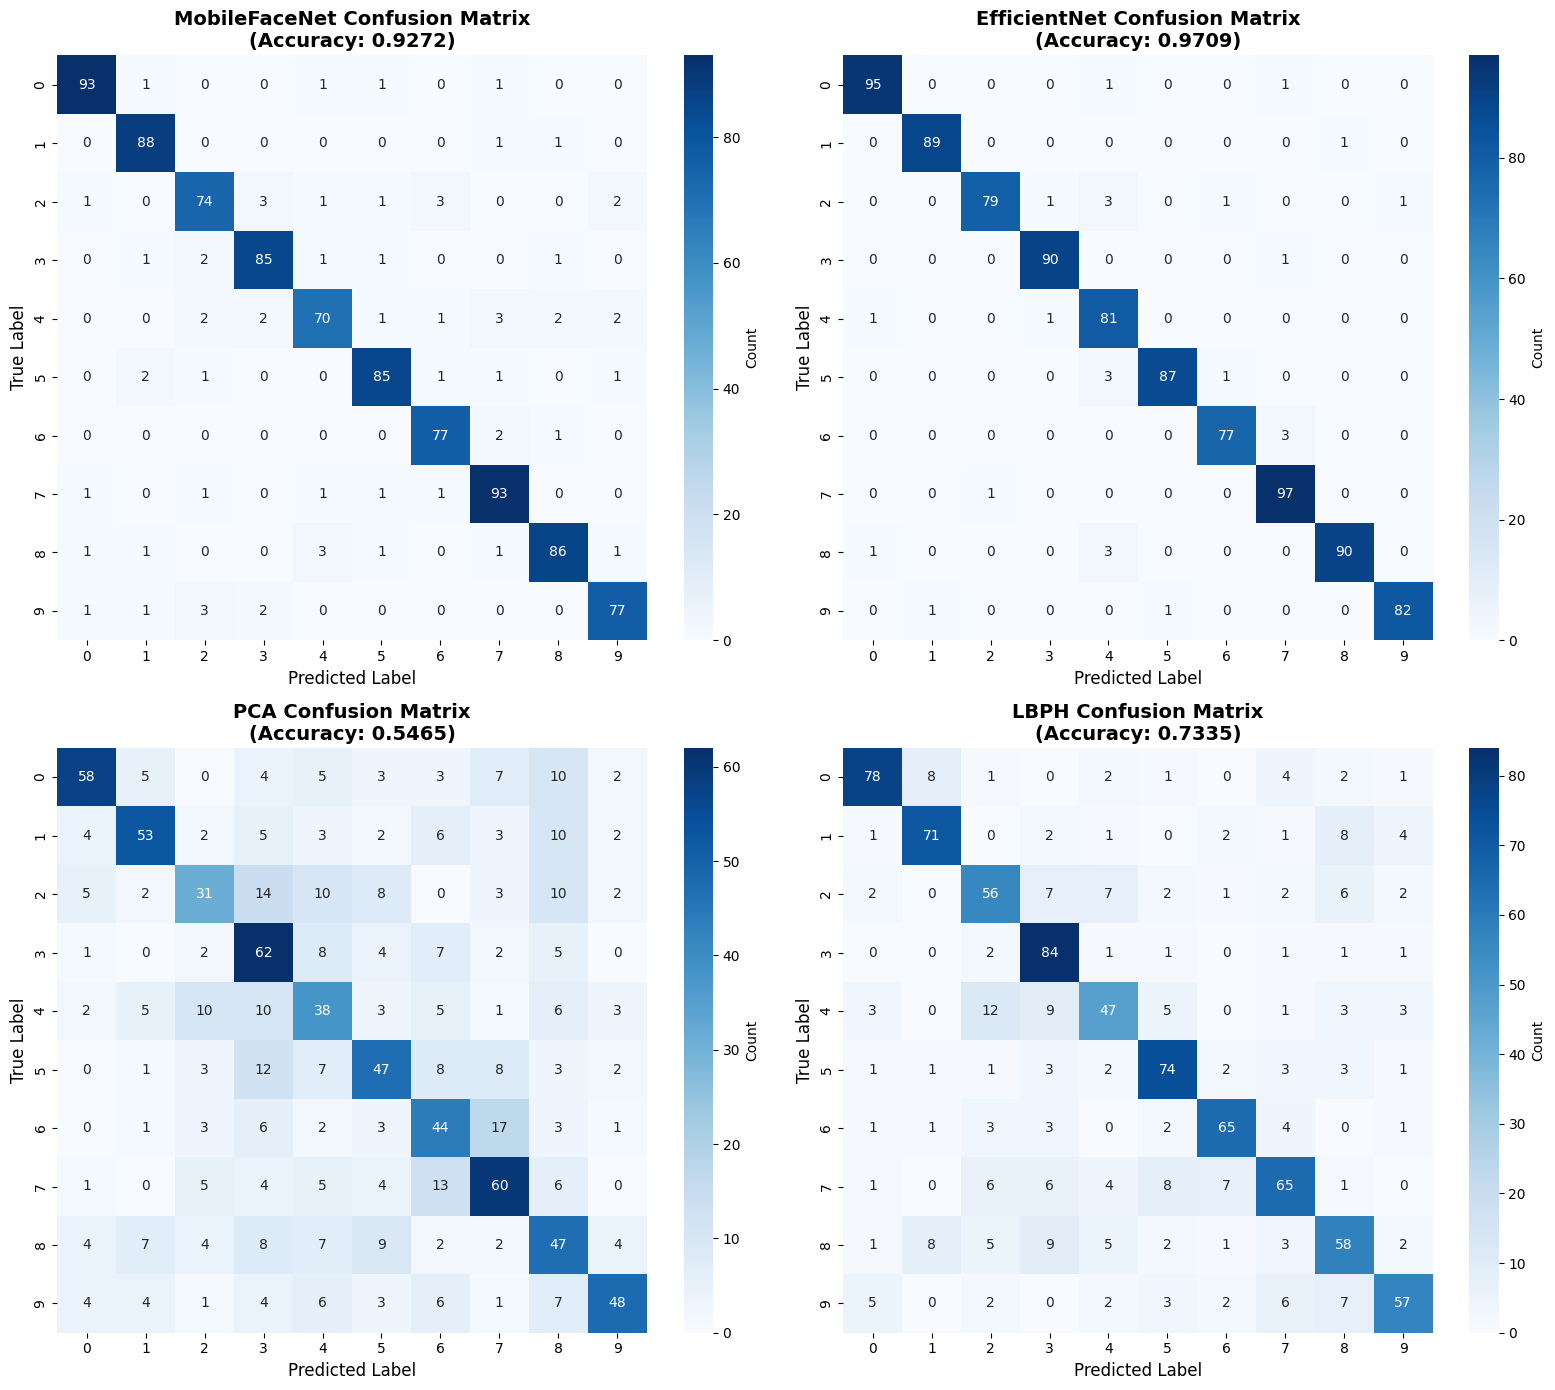


--------------------------------------------------------------------------------
PER-CLASS ACCURACY ANALYSIS
--------------------------------------------------------------------------------

MobileFaceNet:
  Class 0: 0.9588 (93/97)
  Class 1: 0.9778 (88/90)
  Class 2: 0.8706 (74/85)
  Class 3: 0.9341 (85/91)
  Class 4: 0.8434 (70/83)
  Class 5: 0.9341 (85/91)
  Class 6: 0.9625 (77/80)
  Class 7: 0.9490 (93/98)
  Class 8: 0.9149 (86/94)
  Class 9: 0.9167 (77/84)

EfficientNet:
  Class 0: 0.9794 (95/97)
  Class 1: 0.9889 (89/90)
  Class 2: 0.9294 (79/85)
  Class 3: 0.9890 (90/91)
  Class 4: 0.9759 (81/83)
  Class 5: 0.9560 (87/91)
  Class 6: 0.9625 (77/80)
  Class 7: 0.9898 (97/98)
  Class 8: 0.9574 (90/94)
  Class 9: 0.9762 (82/84)

PCA:
  Class 0: 0.5979 (58/97)
  Class 1: 0.5889 (53/90)
  Class 2: 0.3647 (31/85)
  Class 3: 0.6813 (62/91)
  Class 4: 0.4578 (38/83)
  Class 5: 0.5165 (47/91)
  Class 6: 0.5500 (44/80)
  Class 7: 0.6122 (60/98)
  Class 8: 0.5000 (47/94)
  Class 9: 0.5714 

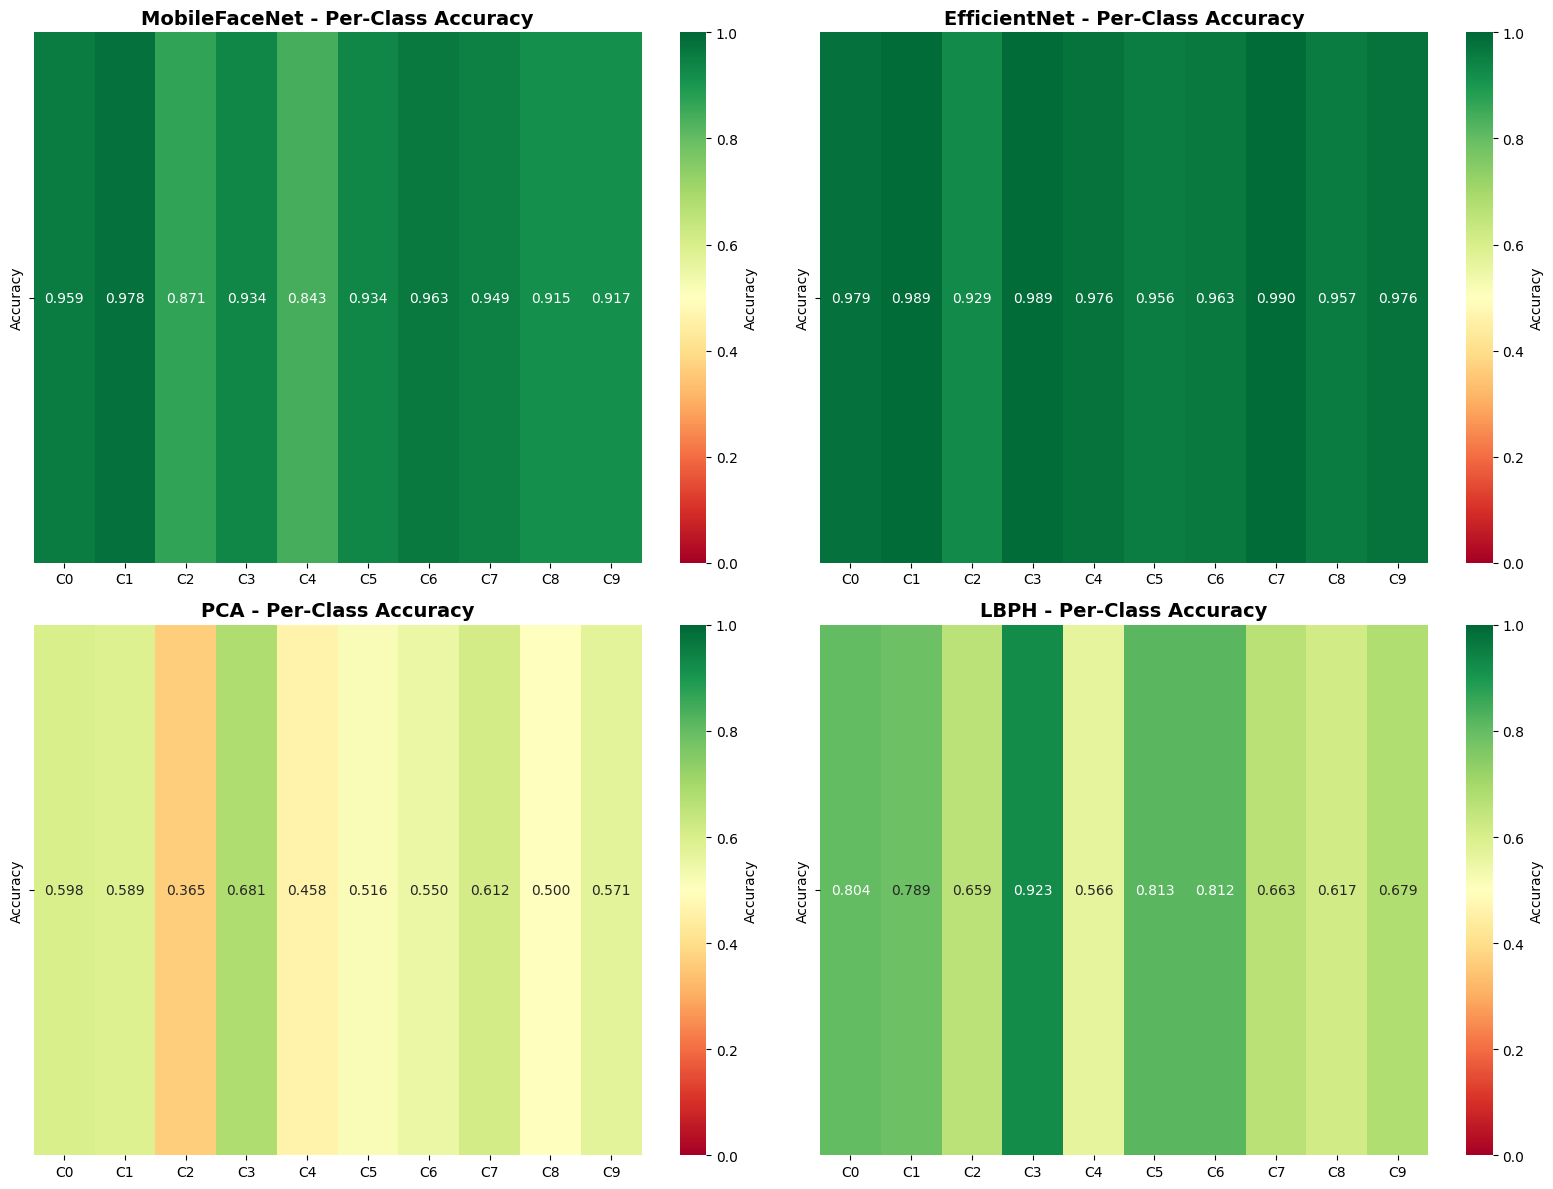

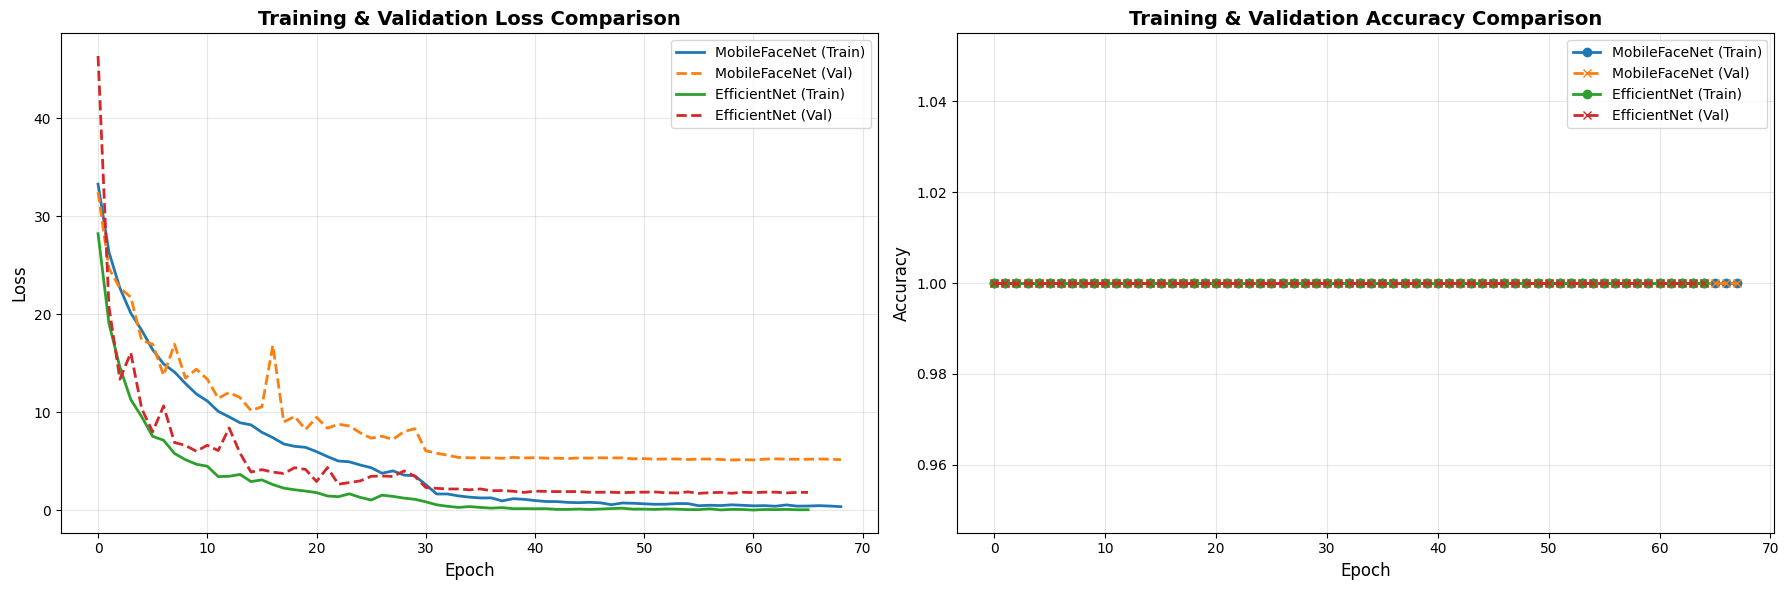

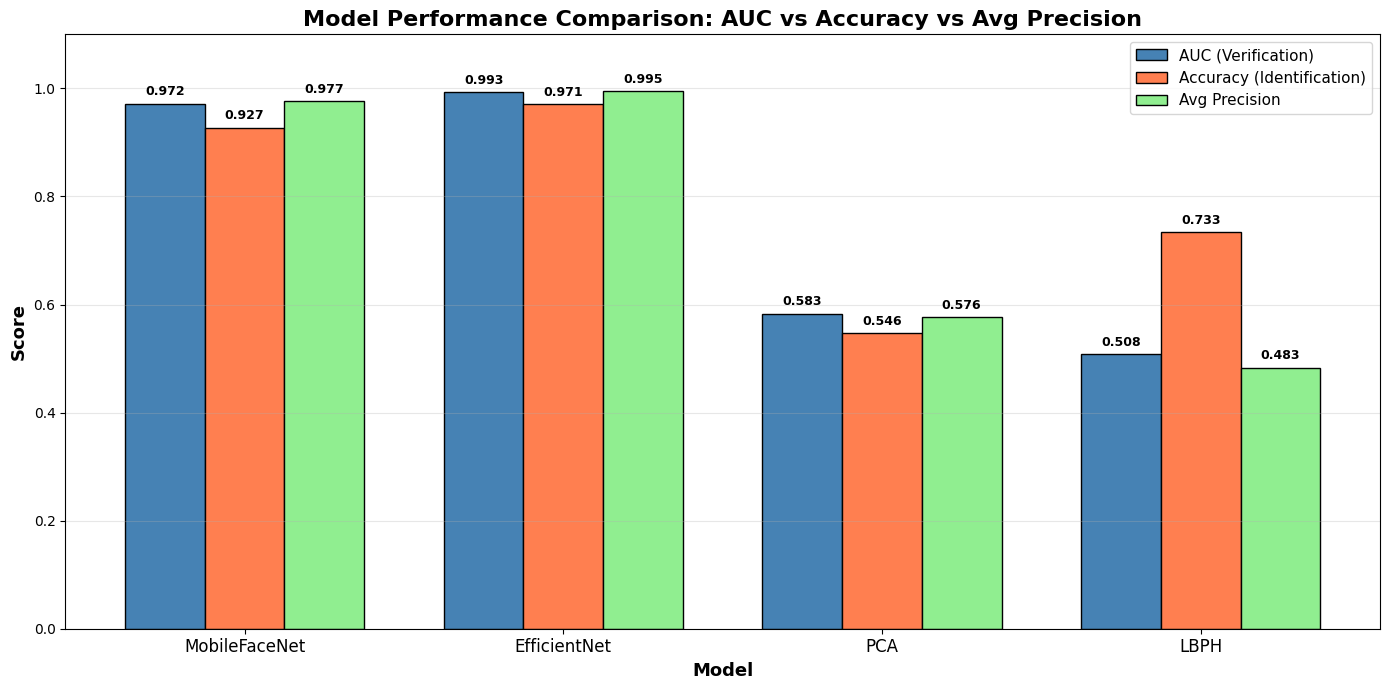


FINAL PERFORMANCE METRICS TABLE
Model                | AUC        | Accuracy   | Avg Precision  
--------------------------------------------------------------------------------
MobileFaceNet        | 0.9717     | 0.9272     | 0.9768         
EfficientNet         | 0.9927     | 0.9709     | 0.9949         
PCA                  | 0.5830     | 0.5465     | 0.5761         
LBPH                 | 0.5080     | 0.7335     | 0.4830         

BEST MODELS:
Best Verification (AUC): EfficientNet (0.9927)
Best Identification (Acc): EfficientNet (0.9709)
Best Avg Precision: EfficientNet (0.9949)


In [14]:
# ============================================================================
# COMPREHENSIVE MODEL COMPARISON & ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("MODEL COMPARISON ANALYSIS")
print("="*80)

# 1. ROC Curves Comparison
plt.figure(figsize=(12, 8))
for name, res in results.items():
    plt.plot(res['fpr'], res['tpr'], label=f"{name} (AUC = {res['auc']:.4f})", linewidth=2.5)
    
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves - Face Verification (All Models)', fontsize=16, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Precision-Recall Curves Comparison
plt.figure(figsize=(12, 8))
for name, res in results.items():
    plt.plot(res['recall'], res['precision'], 
             label=f"{name} (AP = {res['avg_precision']:.4f})", linewidth=2.5)
    
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Precision-Recall Curves - Face Verification (All Models)', fontsize=16, fontweight='bold')
plt.legend(fontsize=11, loc='lower left')
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

# 3. Confusion Matrices (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = res['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                cbar_kws={'label': 'Count'}, annot_kws={'size': 10})
    axes[idx].set_title(f'{name} Confusion Matrix\n(Accuracy: {res["acc"]:.4f})', 
                        fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=12)
    axes[idx].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

# 4. Per-Class Accuracy Analysis
print("\n" + "-"*80)
print("PER-CLASS ACCURACY ANALYSIS")
print("-"*80)

for name, res in results.items():
    cm = res['cm']
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    print(f"\n{name}:")
    for cls_idx, acc in enumerate(per_class_acc):
        print(f"  Class {cls_idx}: {acc:.4f} ({int(cm[cls_idx, cls_idx])}/{int(cm.sum(axis=1)[cls_idx])})")

# Visualization: Per-Class Accuracy Heatmap
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = res['cm']
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    
    # Create heatmap
    acc_matrix = per_class_acc.reshape(1, -1)
    sns.heatmap(acc_matrix, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[idx],
                xticklabels=[f'C{i}' for i in range(len(per_class_acc))],
                yticklabels=['Accuracy'], cbar_kws={'label': 'Accuracy'}, vmin=0, vmax=1)
    axes[idx].set_title(f'{name} - Per-Class Accuracy', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Learning Curves Comparison (for DL models)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Loss curves
for name in ['MobileFaceNet', 'EfficientNet']:
    if name in results and len(results[name]['loss_history']) > 0:
        axes[0].plot(results[name]['loss_history'], label=f'{name} (Train)', linewidth=2)
        axes[0].plot(results[name]['val_loss_history'], label=f'{name} (Val)', 
                     linewidth=2, linestyle='--')

axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Accuracy curves (if available)
for name in ['MobileFaceNet', 'EfficientNet']:
    if name in results and len(results[name]['acc_history']) > 0:
        epochs_acc = list(range(len(results[name]['acc_history'])))
        axes[1].plot(epochs_acc, results[name]['acc_history'], 
                     label=f'{name} (Train)', linewidth=2, marker='o')
        axes[1].plot(epochs_acc, results[name]['val_acc_history'], 
                     label=f'{name} (Val)', linewidth=2, marker='x', linestyle='--')

axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training & Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Model Comparison Bar Charts
models = list(results.keys())
aucs = [results[m]['auc'] for m in models]
accs = [results[m]['acc'] for m in models]
avg_precs = [results[m]['avg_precision'] for m in models]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width, aucs, width, label='AUC (Verification)', color='steelblue', edgecolor='black')
bars2 = ax.bar(x, accs, width, label='Accuracy (Identification)', color='coral', edgecolor='black')
bars3 = ax.bar(x + width, avg_precs, width, label='Avg Precision', color='lightgreen', edgecolor='black')

ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Model Performance Comparison: AUC vs Accuracy vs Avg Precision', 
             fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# 7. Final Metrics Table
print("\n" + "="*80)
print("FINAL PERFORMANCE METRICS TABLE")
print("="*80)
print(f"{'Model':<20} | {'AUC':<10} | {'Accuracy':<10} | {'Avg Precision':<15}")
print("-" * 80)
for name, res in results.items():
    auc_val = res.get('auc', 0)
    acc_val = res.get('acc', 0)
    avg_prec_val = res.get('avg_precision', 0)
    print(f"{name:<20} | {auc_val:<10.4f} | {acc_val:<10.4f} | {avg_prec_val:<15.4f}")

print("\n" + "="*80)
print("BEST MODELS:")
print("="*80)
best_auc_model = max(results.items(), key=lambda x: x[1]['auc'])
best_acc_model = max(results.items(), key=lambda x: x[1]['acc'])
best_ap_model = max(results.items(), key=lambda x: x[1]['avg_precision'])

print(f"Best Verification (AUC): {best_auc_model[0]} ({best_auc_model[1]['auc']:.4f})")
print(f"Best Identification (Acc): {best_acc_model[0]} ({best_acc_model[1]['acc']:.4f})")
print(f"Best Avg Precision: {best_ap_model[0]} ({best_ap_model[1]['avg_precision']:.4f})")
print("="*80)

## 4. Custom Image Prediction
Test all 4 models on a custom image and compare predictions.


CUSTOM IMAGE PREDICTION - TESTING ALL 4 MODELS
Test Image Path: VGGFace2\class107\0245_01.jpg
True Label: 9


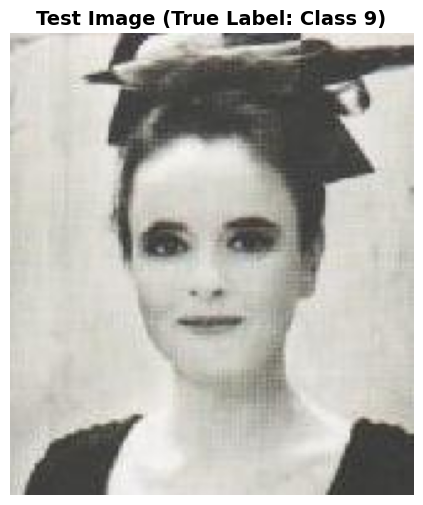


--------------------------------------------------------------------------------
1. MobileFaceNet Prediction
--------------------------------------------------------------------------------
Predicted Label: 9
Confidence (Cosine Similarity): 0.9876
Correct: ✓

--------------------------------------------------------------------------------
2. EfficientNet Prediction
--------------------------------------------------------------------------------
Predicted Label: 9
Confidence (Cosine Similarity): 0.9831
Correct: ✓

--------------------------------------------------------------------------------
3. PCA (Eigenfaces) Prediction
--------------------------------------------------------------------------------
Predicted Label: 9
Confidence (Distance-based): 0.0556
Correct: ✓

--------------------------------------------------------------------------------
4. LBPH Prediction
--------------------------------------------------------------------------------
Predicted Label: 9
Confidence (LBPH Dis

In [20]:
# Select a random test image for prediction
test_image_idx = np.random.choice(len(test_paths))
test_image_path = test_paths[test_image_idx]
true_label = y_test[test_image_idx]

print("\n" + "="*80)
print("CUSTOM IMAGE PREDICTION - TESTING ALL 4 MODELS")
print("="*80)
print(f"Test Image Path: {test_image_path}")
print(f"True Label: {true_label}")
print("="*80)

# Display the test image
test_img_display = Image.open(test_image_path).convert('RGB')
plt.figure(figsize=(6, 6))
plt.imshow(test_img_display)
plt.title(f'Test Image (True Label: Class {true_label})', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

# Prepare predictions dictionary
predictions = {}
confidences = {}

# 1. MobileFaceNet Prediction
print("\n" + "-"*80)
print("1. MobileFaceNet Prediction")
print("-"*80)

mfn_model = MobileFaceNet(embedding_size=512).to(device)
mfn_model.load_state_dict(torch.load('final_models/MobileFaceNet.pth'))
mfn_model.eval()

# Process image
mfn_ds = UnifiedFaceDataset([test_image_path], [true_label], mode='test', model_type='mobilefacenet')
mfn_img, _ = mfn_ds[0]
mfn_img_batch = mfn_img.unsqueeze(0).to(device)

with torch.no_grad():
    mfn_emb = mfn_model(mfn_img_batch).cpu().numpy()[0]
    mfn_emb = mfn_emb / np.maximum(np.linalg.norm(mfn_emb), 1e-10)
    
    # Compare with training embeddings
    train_ds_mfn = UnifiedFaceDataset(train_paths, y_train, mode='test', model_type='mobilefacenet')
    train_dl_mfn = DataLoader(train_ds_mfn, batch_size=32, shuffle=False)
    
    train_embs_mfn = []
    train_lbls_mfn = []
    for imgs, lbls in train_dl_mfn:
        embs = mfn_model(imgs.to(device)).cpu().numpy()
        train_embs_mfn.append(embs)
        train_lbls_mfn.append(lbls.numpy())
    
    train_embs_mfn = np.concatenate(train_embs_mfn)
    train_lbls_mfn = np.concatenate(train_lbls_mfn)
    train_embs_mfn = train_embs_mfn / np.maximum(np.linalg.norm(train_embs_mfn, axis=1, keepdims=True), 1e-10)
    
    # Find nearest neighbor
    similarities_mfn = np.dot(train_embs_mfn, mfn_emb)
    best_match_idx = np.argmax(similarities_mfn)
    pred_label_mfn = train_lbls_mfn[best_match_idx]
    confidence_mfn = similarities_mfn[best_match_idx]
    
    predictions['MobileFaceNet'] = pred_label_mfn
    confidences['MobileFaceNet'] = confidence_mfn
    
    print(f"Predicted Label: {pred_label_mfn}")
    print(f"Confidence (Cosine Similarity): {confidence_mfn:.4f}")
    print(f"Correct: {'✓' if pred_label_mfn == true_label else '✗'}")

# 2. EfficientNet Prediction
print("\n" + "-"*80)
print("2. EfficientNet Prediction")
print("-"*80)

eff_model = EfficientNetArcFace(embedding_size=1280).to(device)
eff_model.load_state_dict(torch.load('final_models/EfficientNet.pth'))
eff_model.eval()

eff_ds = UnifiedFaceDataset([test_image_path], [true_label], mode='test', model_type='efficientnet')
eff_img, _ = eff_ds[0]
eff_img_batch = eff_img.unsqueeze(0).to(device)

with torch.no_grad():
    eff_emb = eff_model(eff_img_batch).cpu().numpy()[0]
    eff_emb = eff_emb / np.maximum(np.linalg.norm(eff_emb), 1e-10)
    
    # Get training embeddings
    train_ds_eff = UnifiedFaceDataset(train_paths, y_train, mode='test', model_type='efficientnet')
    train_dl_eff = DataLoader(train_ds_eff, batch_size=32, shuffle=False)
    
    train_embs_eff = []
    train_lbls_eff = []
    for imgs, lbls in train_dl_eff:
        embs = eff_model(imgs.to(device)).cpu().numpy()
        train_embs_eff.append(embs)
        train_lbls_eff.append(lbls.numpy())
    
    train_embs_eff = np.concatenate(train_embs_eff)
    train_lbls_eff = np.concatenate(train_lbls_eff)
    train_embs_eff = train_embs_eff / np.maximum(np.linalg.norm(train_embs_eff, axis=1, keepdims=True), 1e-10)
    
    similarities_eff = np.dot(train_embs_eff, eff_emb)
    best_match_idx = np.argmax(similarities_eff)
    pred_label_eff = train_lbls_eff[best_match_idx]
    confidence_eff = similarities_eff[best_match_idx]
    
    predictions['EfficientNet'] = pred_label_eff
    confidences['EfficientNet'] = confidence_eff
    
    print(f"Predicted Label: {pred_label_eff}")
    print(f"Confidence (Cosine Similarity): {confidence_eff:.4f}")
    print(f"Correct: {'✓' if pred_label_eff == true_label else '✗'}")

# 3. PCA Prediction
print("\n" + "-"*80)
print("3. PCA (Eigenfaces) Prediction")
print("-"*80)

pca_ds = UnifiedFaceDataset([test_image_path], [true_label], mode='test', model_type='pca')
pca_img, _ = pca_ds[0]

pred_label_pca = pca.predict(pca_img.reshape(1, -1))[0]
predictions['PCA'] = pred_label_pca

# Calculate confidence as inverse distance
pca_emb = pca.get_embeddings(pca_img.reshape(1, -1))[0]
distances = np.linalg.norm(pca.projections - pca_emb, axis=1)
min_dist = np.min(distances)
confidence_pca = 1.0 / (1.0 + min_dist)  # Convert distance to confidence
confidences['PCA'] = confidence_pca

print(f"Predicted Label: {pred_label_pca}")
print(f"Confidence (Distance-based): {confidence_pca:.4f}")
print(f"Correct: {'✓' if pred_label_pca == true_label else '✗'}")

# 4. LBPH Prediction
print("\n" + "-"*80)
print("4. LBPH Prediction")
print("-"*80)

lbph_ds = UnifiedFaceDataset([test_image_path], [true_label], mode='test', model_type='lbph')
lbph_img, _ = lbph_ds[0]

pred_label_lbph, lbph_conf = lbph.predict(lbph_img)
predictions['LBPH'] = pred_label_lbph

# Convert LBPH confidence (lower is better) to normalized confidence
confidence_lbph = 1.0 / (1.0 + lbph_conf / 100.0)  # Normalize
confidences['LBPH'] = confidence_lbph

print(f"Predicted Label: {pred_label_lbph}")
print(f"Confidence (LBPH Distance): {lbph_conf:.2f} -> Normalized: {confidence_lbph:.4f}")
print(f"Correct: {'✓' if pred_label_lbph == true_label else '✗'}")


PREDICTION SUMMARY


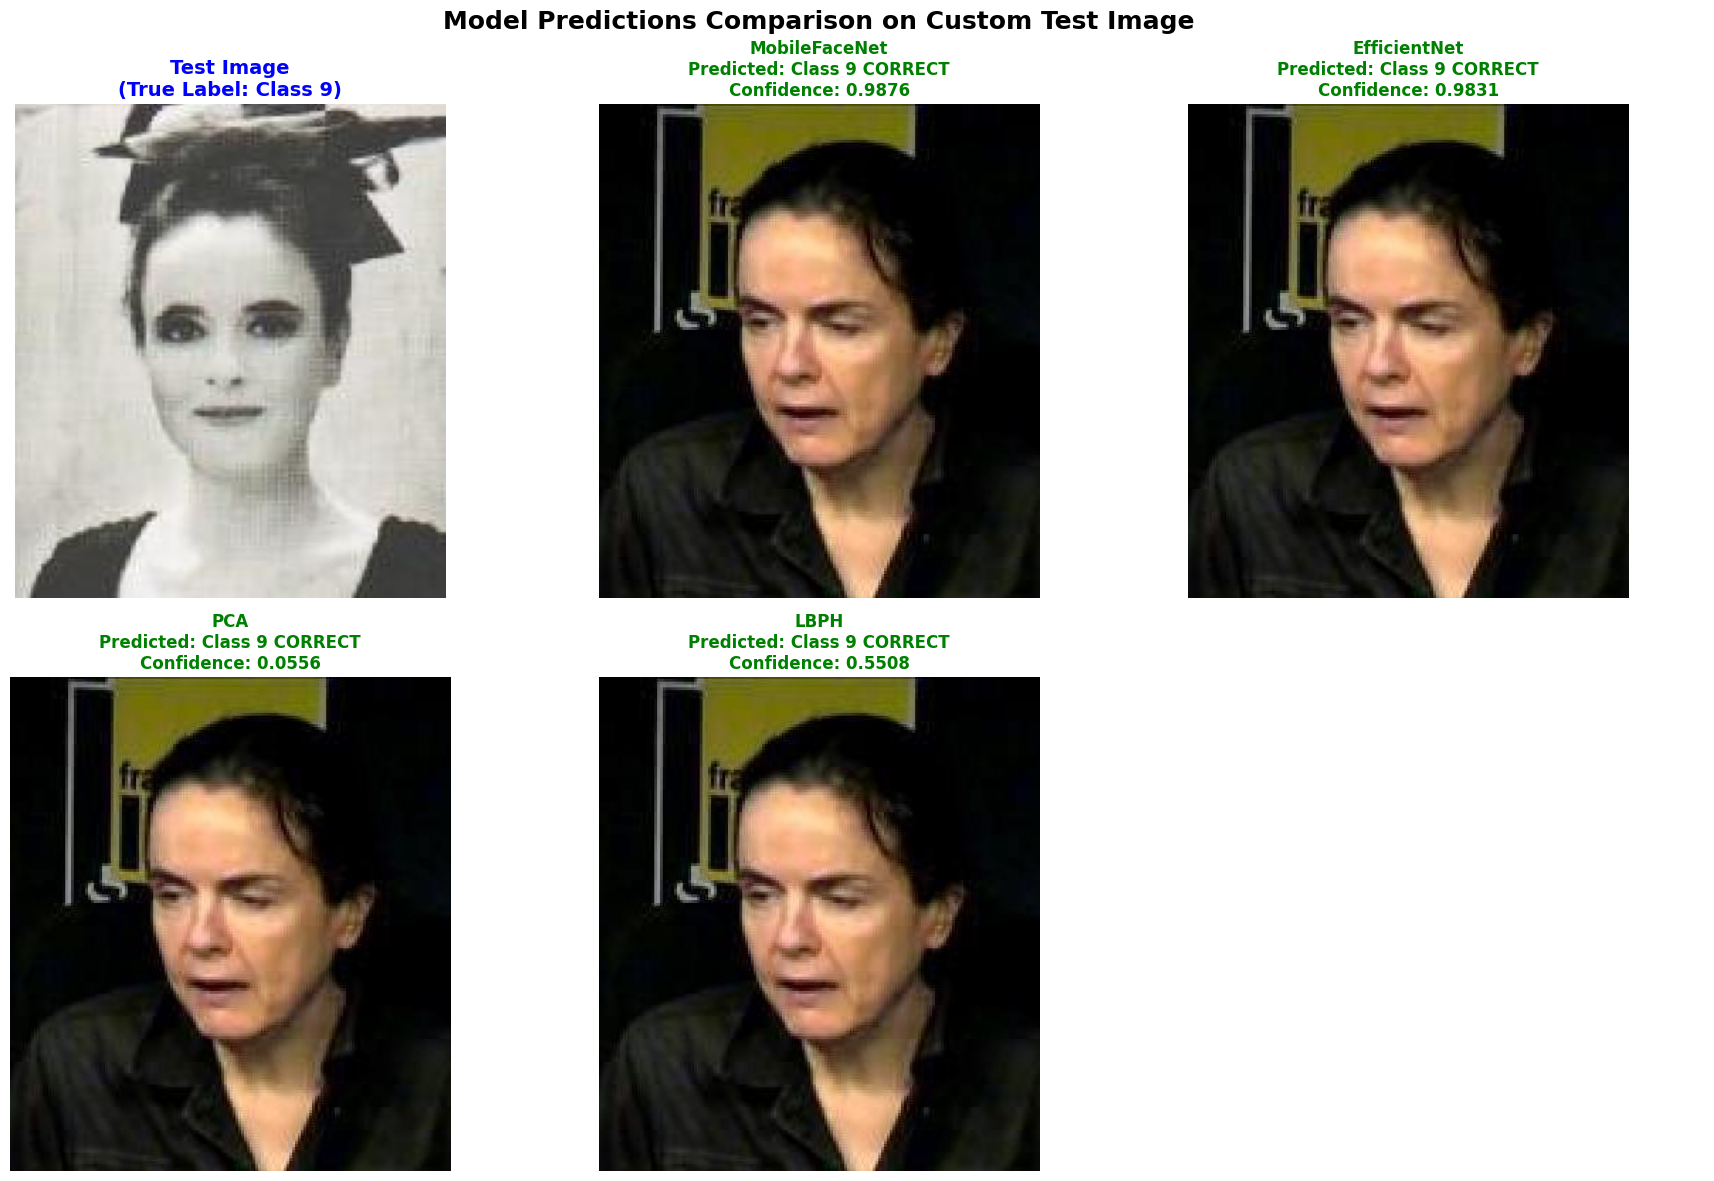

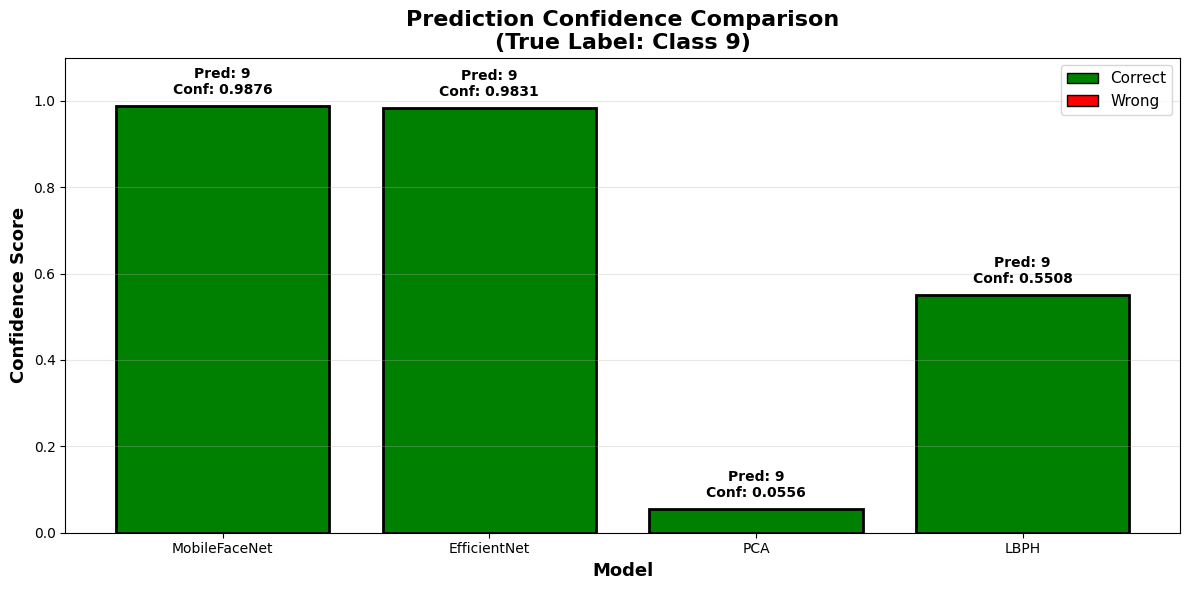


--------------------------------------------------------------------------------
Model                | Predicted    | Confidence   | Status    
--------------------------------------------------------------------------------
MobileFaceNet        | 9            | 0.9876       | Correct   
EfficientNet         | 9            | 0.9831       | Correct   
PCA                  | 9            | 0.0556       | Correct   
LBPH                 | 9            | 0.5508       | Correct   
--------------------------------------------------------------------------------

Ensemble Prediction (Majority Vote): Class 9
Ensemble Result: CORRECT
Individual Correct: 4/4


In [22]:
# Summary Visualization
print("\n" + "="*80)
print("PREDICTION SUMMARY")
print("="*80)

# Create comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Display test image in first position
axes[0, 0].imshow(test_img_display)
axes[0, 0].set_title(f'Test Image\n(True Label: Class {true_label})', 
                     fontsize=14, fontweight='bold', color='blue')
axes[0, 0].axis('off')

# Display predictions for each model
model_names = list(predictions.keys())
for idx, model_name in enumerate(model_names):
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    
    pred_label = predictions[model_name]
    conf = confidences[model_name]
    is_correct = pred_label == true_label
    
    # Find a sample image from predicted class
    pred_class_indices = np.where(y_train == pred_label)[0]
    if len(pred_class_indices) > 0:
        sample_idx = pred_class_indices[0]
        sample_img = Image.open(train_paths[sample_idx]).convert('RGB')
    else:
        sample_img = Image.new('RGB', (100, 100), color='gray')
    
    axes[row, col].imshow(sample_img)
    
    title_color = 'green' if is_correct else 'red'
    status = 'CORRECT' if is_correct else 'WRONG'
    
    axes[row, col].set_title(
        f'{model_name}\nPredicted: Class {pred_label} {status}\nConfidence: {conf:.4f}',
        fontsize=12, fontweight='bold', color=title_color
    )
    axes[row, col].axis('off')

# Hide last subplot if not used
if len(model_names) < 5:
    axes[1, 2].axis('off')

plt.suptitle('Model Predictions Comparison on Custom Test Image', 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Confidence comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))
model_names_list = list(predictions.keys())
pred_labels_list = [predictions[m] for m in model_names_list]
conf_list = [confidences[m] for m in model_names_list]
colors_list = ['green' if predictions[m] == true_label else 'red' for m in model_names_list]

bars = ax.bar(model_names_list, conf_list, color=colors_list, edgecolor='black', linewidth=2)
ax.set_ylabel('Confidence Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_title(f'Prediction Confidence Comparison\n(True Label: Class {true_label})', 
             fontsize=16, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Add value labels and predictions on bars
for idx, (bar, pred, conf) in enumerate(zip(bars, pred_labels_list, conf_list)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'Pred: {pred}\nConf: {conf:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', edgecolor='black', label='Correct'),
                   Patch(facecolor='red', edgecolor='black', label='Wrong')]
ax.legend(handles=legend_elements, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "-"*80)
print(f"{'Model':<20} | {'Predicted':<12} | {'Confidence':<12} | {'Status':<10}")
print("-"*80)
for model_name in model_names_list:
    pred = predictions[model_name]
    conf = confidences[model_name]
    status = 'Correct' if pred == true_label else 'Wrong'
    print(f"{model_name:<20} | {pred:<12} | {conf:<12.4f} | {status:<10}")
print("-"*80)

# Calculate ensemble prediction (majority voting)
from collections import Counter
pred_counts = Counter(predictions.values())
ensemble_pred = pred_counts.most_common(1)[0][0]
ensemble_correct = ensemble_pred == true_label

print(f"\nEnsemble Prediction (Majority Vote): Class {ensemble_pred}")
print(f"Ensemble Result: {'CORRECT' if ensemble_correct else 'WRONG'}")
print(f"Individual Correct: {sum([1 for m in model_names_list if predictions[m] == true_label])}/{len(model_names_list)}")
print("="*80)

## 4.1 Batch Custom Image Prediction
Test multiple random images to get overall accuracy on custom predictions.


BATCH PREDICTION TEST ON 20 RANDOM IMAGES

Image 1/20: True Label = 2
  MobileFaceNet: ✓ Correct (Pred: 2)
  EfficientNet: ✓ Correct (Pred: 2)
  PCA: ✗ Wrong (Pred: 8)
  LBPH: ✗ Wrong (Pred: 4)

Image 2/20: True Label = 1
  MobileFaceNet: ✓ Correct (Pred: 1)
  EfficientNet: ✓ Correct (Pred: 1)
  PCA: ✓ Correct (Pred: 1)
  LBPH: ✓ Correct (Pred: 1)

Image 3/20: True Label = 7
  MobileFaceNet: ✓ Correct (Pred: 7)
  EfficientNet: ✓ Correct (Pred: 7)
  PCA: ✓ Correct (Pred: 7)
  LBPH: ✗ Wrong (Pred: 0)

Image 4/20: True Label = 5
  MobileFaceNet: ✓ Correct (Pred: 5)
  EfficientNet: ✓ Correct (Pred: 5)
  PCA: ✗ Wrong (Pred: 7)
  LBPH: ✗ Wrong (Pred: 6)

Image 5/20: True Label = 7
  MobileFaceNet: ✓ Correct (Pred: 7)
  EfficientNet: ✓ Correct (Pred: 7)
  PCA: ✗ Wrong (Pred: 3)
  LBPH: ✓ Correct (Pred: 7)

Image 6/20: True Label = 9
  MobileFaceNet: ✓ Correct (Pred: 9)
  EfficientNet: ✓ Correct (Pred: 9)
  PCA: ✓ Correct (Pred: 9)
  LBPH: ✓ Correct (Pred: 9)

Image 7/20: True Label = 0
  Mob

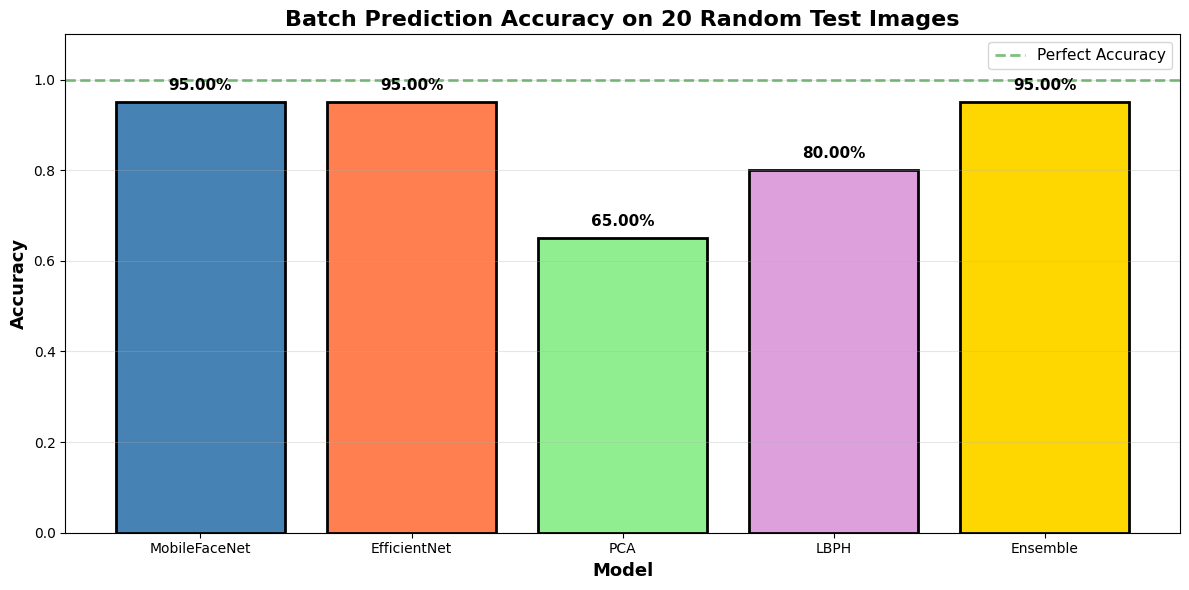

In [18]:
# Test on multiple random images
n_test_samples = min(20, len(test_paths))
test_indices = np.random.choice(len(test_paths), n_test_samples, replace=False)

print("\n" + "="*80)
print(f"BATCH PREDICTION TEST ON {n_test_samples} RANDOM IMAGES")
print("="*80)

batch_results = {model: {'correct': 0, 'total': 0} for model in ['MobileFaceNet', 'EfficientNet', 'PCA', 'LBPH']}
ensemble_correct = 0

for idx, test_idx in enumerate(test_indices):
    test_path = test_paths[test_idx]
    true_lbl = y_test[test_idx]
    
    print(f"\nImage {idx+1}/{n_test_samples}: True Label = {true_lbl}")
    
    # Get predictions from all models
    preds = {}
    
    # MobileFaceNet
    mfn_ds_temp = UnifiedFaceDataset([test_path], [true_lbl], mode='test', model_type='mobilefacenet')
    mfn_img_temp, _ = mfn_ds_temp[0]
    with torch.no_grad():
        mfn_emb_temp = mfn_model(mfn_img_temp.unsqueeze(0).to(device)).cpu().numpy()[0]
        mfn_emb_temp = mfn_emb_temp / np.maximum(np.linalg.norm(mfn_emb_temp), 1e-10)
        sims = np.dot(train_embs_mfn, mfn_emb_temp)
        preds['MobileFaceNet'] = train_lbls_mfn[np.argmax(sims)]
    
    # EfficientNet
    eff_ds_temp = UnifiedFaceDataset([test_path], [true_lbl], mode='test', model_type='efficientnet')
    eff_img_temp, _ = eff_ds_temp[0]
    with torch.no_grad():
        eff_emb_temp = eff_model(eff_img_temp.unsqueeze(0).to(device)).cpu().numpy()[0]
        eff_emb_temp = eff_emb_temp / np.maximum(np.linalg.norm(eff_emb_temp), 1e-10)
        sims = np.dot(train_embs_eff, eff_emb_temp)
        preds['EfficientNet'] = train_lbls_eff[np.argmax(sims)]
    
    # PCA
    pca_ds_temp = UnifiedFaceDataset([test_path], [true_lbl], mode='test', model_type='pca')
    pca_img_temp, _ = pca_ds_temp[0]
    preds['PCA'] = pca.predict(pca_img_temp.reshape(1, -1))[0]
    
    # LBPH
    lbph_ds_temp = UnifiedFaceDataset([test_path], [true_lbl], mode='test', model_type='lbph')
    lbph_img_temp, _ = lbph_ds_temp[0]
    preds['LBPH'], _ = lbph.predict(lbph_img_temp)
    
    # Update results
    for model, pred in preds.items():
        batch_results[model]['total'] += 1
        if pred == true_lbl:
            batch_results[model]['correct'] += 1
            print(f"  {model}: ✓ Correct (Pred: {pred})")
        else:
            print(f"  {model}: ✗ Wrong (Pred: {pred})")
    
    # Ensemble
    pred_counts = Counter(preds.values())
    ensemble_pred = pred_counts.most_common(1)[0][0]
    if ensemble_pred == true_lbl:
        ensemble_correct += 1

# Print final batch results
print("\n" + "="*80)
print("BATCH PREDICTION RESULTS SUMMARY")
print("="*80)
print(f"{'Model':<20} | {'Correct':<10} | {'Total':<10} | {'Accuracy':<10}")
print("-"*80)

for model in batch_results:
    correct = batch_results[model]['correct']
    total = batch_results[model]['total']
    acc = correct / total if total > 0 else 0
    print(f"{model:<20} | {correct:<10} | {total:<10} | {acc:<10.4f}")

ensemble_acc = ensemble_correct / n_test_samples
print(f"{'Ensemble (Voting)':<20} | {ensemble_correct:<10} | {n_test_samples:<10} | {ensemble_acc:<10.4f}")
print("="*80)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
model_names = list(batch_results.keys()) + ['Ensemble']
accuracies = [batch_results[m]['correct']/batch_results[m]['total'] for m in batch_results.keys()] + [ensemble_acc]
colors = ['steelblue', 'coral', 'lightgreen', 'plum', 'gold']

bars = ax.bar(model_names, accuracies, color=colors[:len(model_names)], edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_title(f'Batch Prediction Accuracy on {n_test_samples} Random Test Images', 
             fontsize=16, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Perfect Accuracy')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=11)

# Add value labels
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{acc:.2%}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()